In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.cluster import KMeans
import time
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
from sklearn.metrics import classification_report , confusion_matrix ,f1_score,accuracy_score
from imblearn.over_sampling import SMOTENC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier , RandomForestClassifier , StackingClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import RFE
import scipy.stats as stats
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
# import squarify

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataIBM.csv', delimiter=';')

In [3]:
# Additional imports for the EDA visualisations
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.facecolor"] = "white"


## Data Exploration

### Basic Exploration

Check the columns, dtypes and dimensions.

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Structure du dataset :**

- **1 470 lignes × 35 colonnes**
- **26 variables numériques** (int64) et **9 variables catégorielles** (object)
- **0 valeur manquante** → pas d'imputation nécessaire
- La cible `Attrition` est binaire (`Yes` / `No`) → **problème de classification binaire**
- `EmployeeNumber` est un identifiant → à exclure de la modélisation


### Statistical Exploration

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
df.describe(include=['O'])

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


**Observations statistiques :**

- Les *rate variables* (`DailyRate`, `HourlyRate`, `MonthlyRate`) sont presque **uniformément distribuées** (skew ≈ 0) → leur pouvoir discriminant est probablement faible.
- `MonthlyIncome` va de **1 009 à 19 999** avec une médiane à **4 919** → forte dispersion des salaires.
- `Age` varie de **18 à 60 ans**, moyenne ≈ 37 → population jeune-mature.
- Les variables ordinales de satisfaction (échelle 1→4) ont une médiane à 3.


**Colonnes à supprimer avant modélisation (aucun pouvoir prédictif) :**

- `EmployeeCount` = 1 (constante)
- `Over18` = 'Y' (constante)
- `StandardHours` = 80 (constante)
- `EmployeeNumber` (identifiant unique)


In [8]:
# Skewness of numerical features
df.skew(numeric_only=True).sort_values(ascending=False)

YearsSinceLastPromotion     1.984290
PerformanceRating           1.921883
YearsAtCompany              1.764529
MonthlyIncome               1.369817
TotalWorkingYears           1.117172
NumCompaniesWorked          1.026471
JobLevel                    1.025401
StockOptionLevel            0.968980
DistanceFromHome            0.958118
YearsInCurrentRole          0.917363
YearsWithCurrManager        0.833451
PercentSalaryHike           0.821128
TrainingTimesLastYear       0.553124
Age                         0.413286
MonthlyRate                 0.018578
EmployeeNumber              0.016574
StandardHours               0.000000
EmployeeCount               0.000000
DailyRate                  -0.003519
HourlyRate                 -0.032311
Education                  -0.289681
RelationshipSatisfaction   -0.302828
EnvironmentSatisfaction    -0.321654
JobSatisfaction            -0.329672
JobInvolvement             -0.498419
WorkLifeBalance            -0.552480
dtype: float64

**Interprétation de la skewness :**

- **Fortement asymétriques à droite** (skew > 1) : `YearsSinceLastPromotion` (1.98), `PerformanceRating` (1.92), `YearsAtCompany` (1.76), `MonthlyIncome` (1.37), `TotalWorkingYears` (1.12), `NumCompaniesWorked` (1.03), `JobLevel` (1.03) → une **transformation log** peut aider pour les modèles linéaires (inutile pour Random Forest / XGBoost).
- **Modérément asymétriques à gauche** : `WorkLifeBalance` (-0.55), `JobInvolvement` (-0.50) → la majorité des employés se déclare plutôt satisfaite.
- **Proches d'une uniforme** (|skew| < 0.05) : `DailyRate`, `HourlyRate`, `MonthlyRate` → **pas de signal exploitable** dans ces variables.
- `EmployeeNumber`, `StandardHours`, `EmployeeCount` : ID ou constantes → à retirer.


#### Missing Values

In [9]:
df.isnull().sum().sum()

np.int64(0)

- No missing values to handle.

---

## Visual Exploratory Data Analysis

Now let's dive into the visual EDA to uncover patterns behind employee attrition.

### EDA 1 — Target Distribution (Attrition)

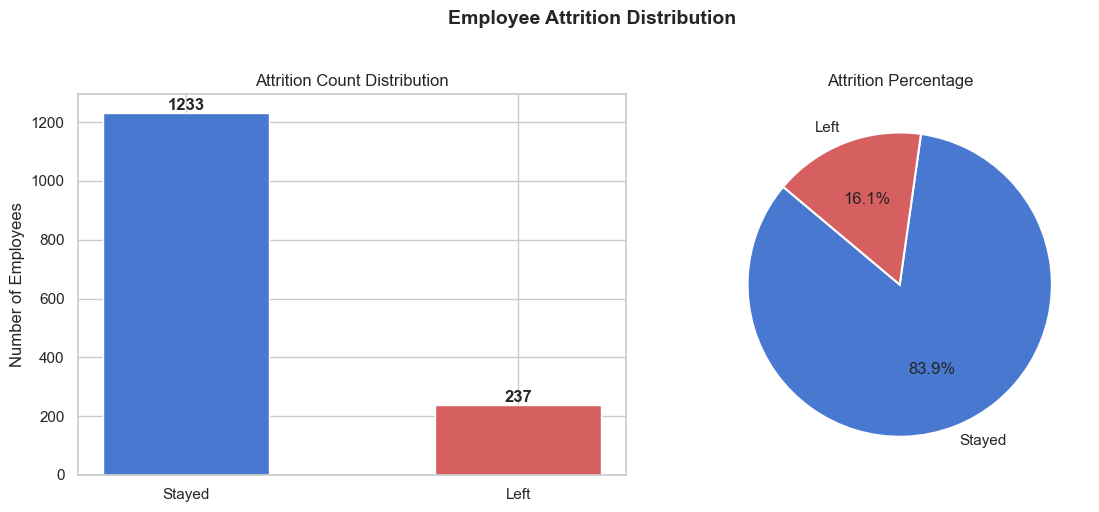

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Stayed", "Left"]
counts = df["Attrition"].value_counts()
# Ensure order: No first, Yes second
counts = counts.reindex(["No", "Yes"])
colors = ["#4878CF", "#D65F5F"]

axes[0].bar(labels, counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Attrition Count Distribution")
axes[0].set_ylabel("Number of Employees")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Attrition Percentage")

plt.suptitle("Employee Attrition Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Observation :** Le dataset est fortement déséquilibré — environ **83.9 %** d'employés sont restés contre **16.1 %** ayant quitté (ratio ≈ **5.2 : 1**).

**Conséquence pour la modélisation :**
- L'**accuracy** seule est trompeuse (un modèle qui prédit toujours "No" atteindrait 83.9 %).
- Suivre plutôt le **F1-score**, le **recall de la classe "Yes"**, la **precision** et la **ROC-AUC**.
- Utiliser **SMOTE / SMOTENC** ou **class_weight='balanced'** lors de l'entraînement.


### EDA 2 — Numerical Feature Distributions

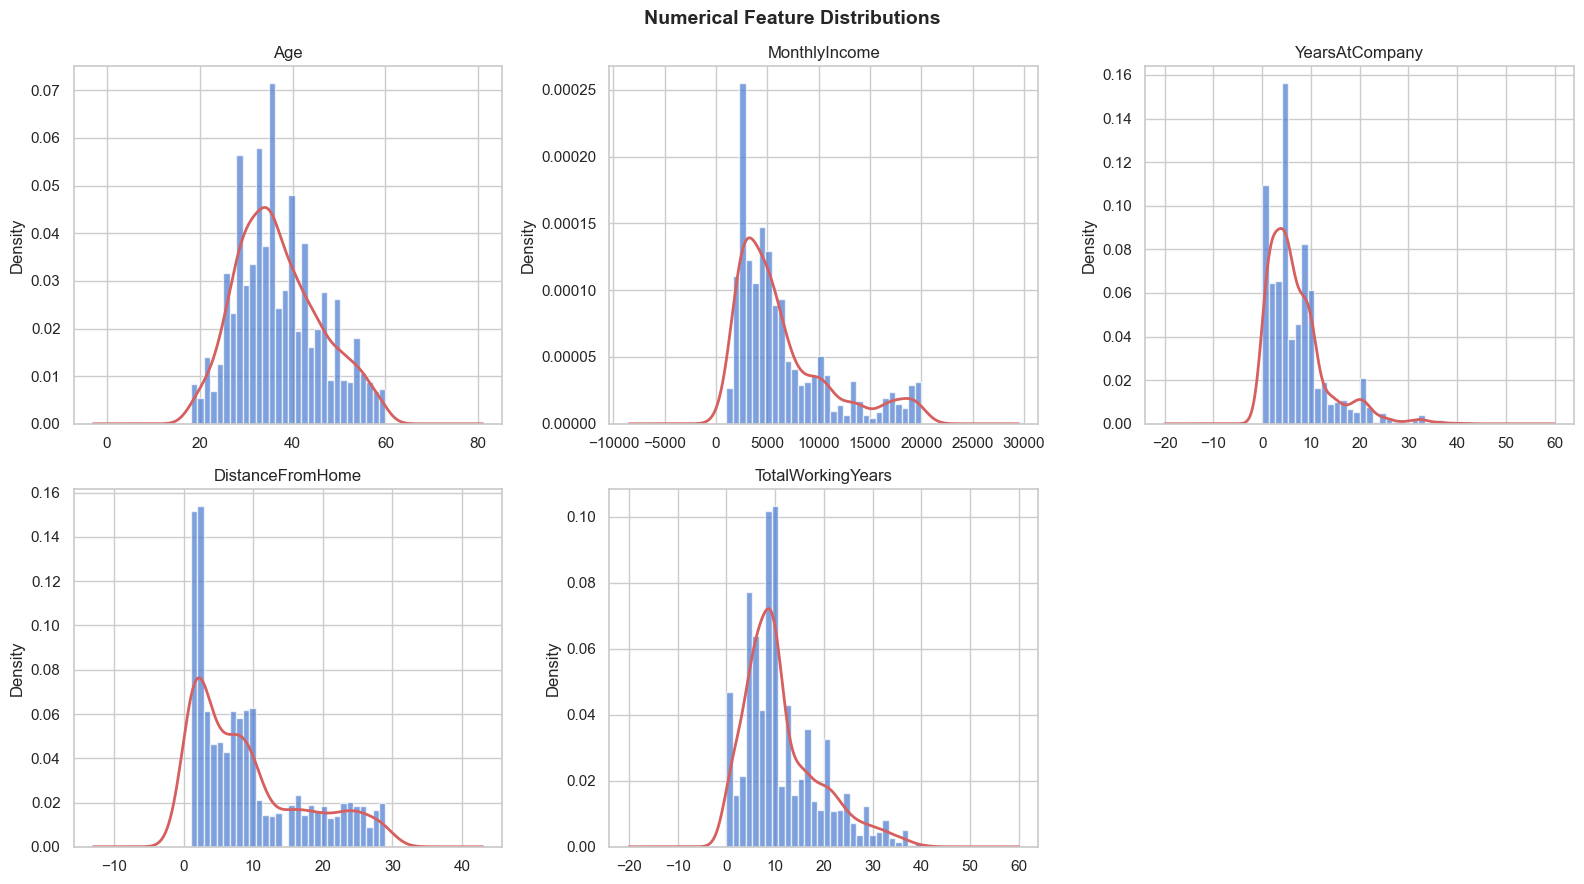

In [11]:
num_features = ["Age", "MonthlyIncome", "YearsAtCompany",
                "DistanceFromHome", "TotalWorkingYears"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=30, color="#4878CF", edgecolor="white",
                 alpha=0.7, density=True)
    df[col].plot(kind="kde", ax=axes[i], color="#D65F5F", linewidth=2)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

axes[-1].set_visible(False)

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:** `MonthlyIncome`, `YearsAtCompany`, `DistanceFromHome` and `TotalWorkingYears` are right-skewed. `Age` is closer to a normal distribution.

### EDA 3 — Categorical Feature Distributions

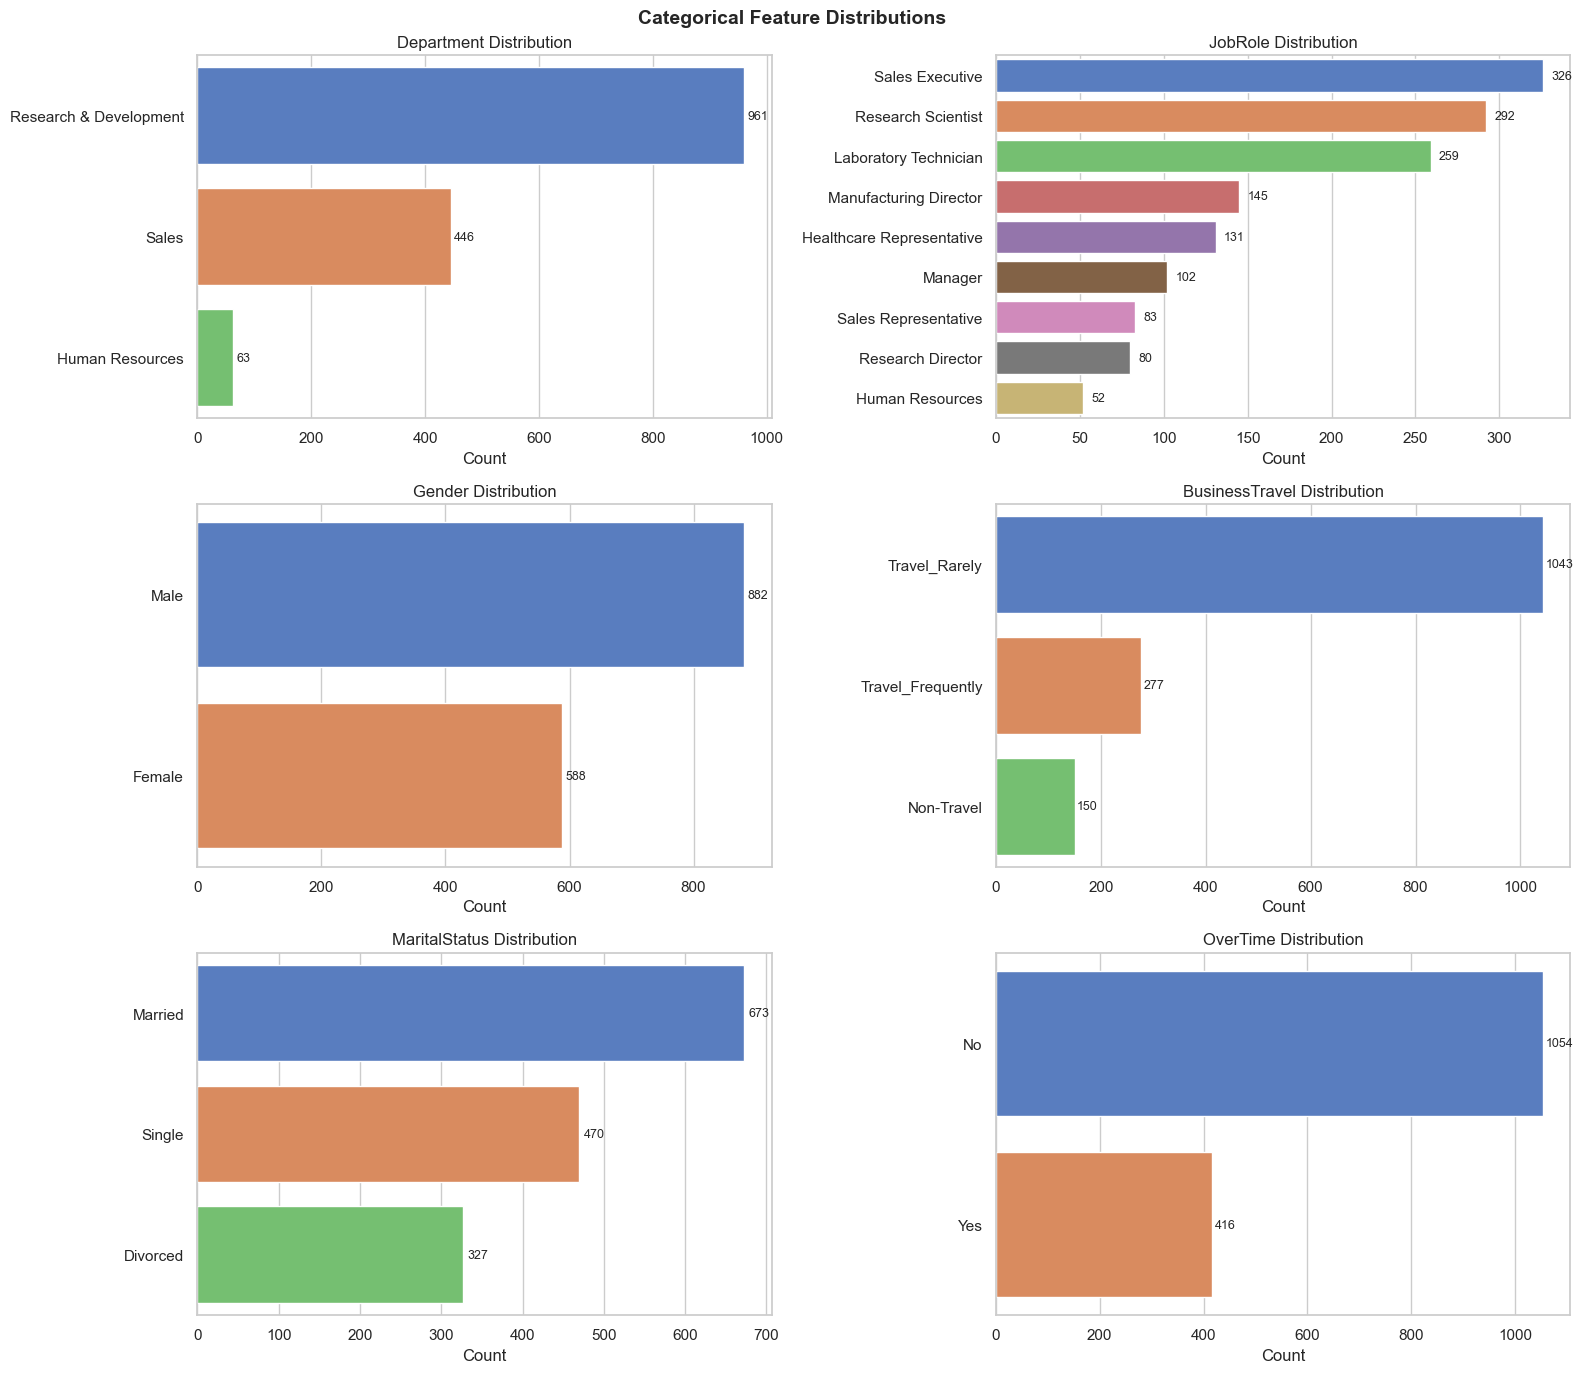

In [12]:
cat_features = ["Department", "JobRole", "Gender",
                "BusinessTravel", "MaritalStatus", "OverTime"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="muted")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")
    for p in axes[i].patches:
        axes[i].annotate(
            f"{int(p.get_width())}",
            (p.get_width() + 5, p.get_y() + p.get_height() / 2),
            va="center", fontsize=9
        )

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations sur les catégorielles :**

- **Department** dominé par R&D (~65 %), Sales (~30 %), HR (~4 %).
- **JobRole** : les 3 rôles majoritaires sont *Sales Executive*, *Research Scientist*, *Laboratory Technician*.
- **Gender** : ~60 % Male / 40 % Female — léger déséquilibre.
- **BusinessTravel** : la majorité voyage rarement, mais ~28 % voyagent fréquemment.
- **OverTime** : ~28 % des employés font des heures supplémentaires — **variable clé** (voir EDA 4).


### EDA 4 — Attrition vs Key Features

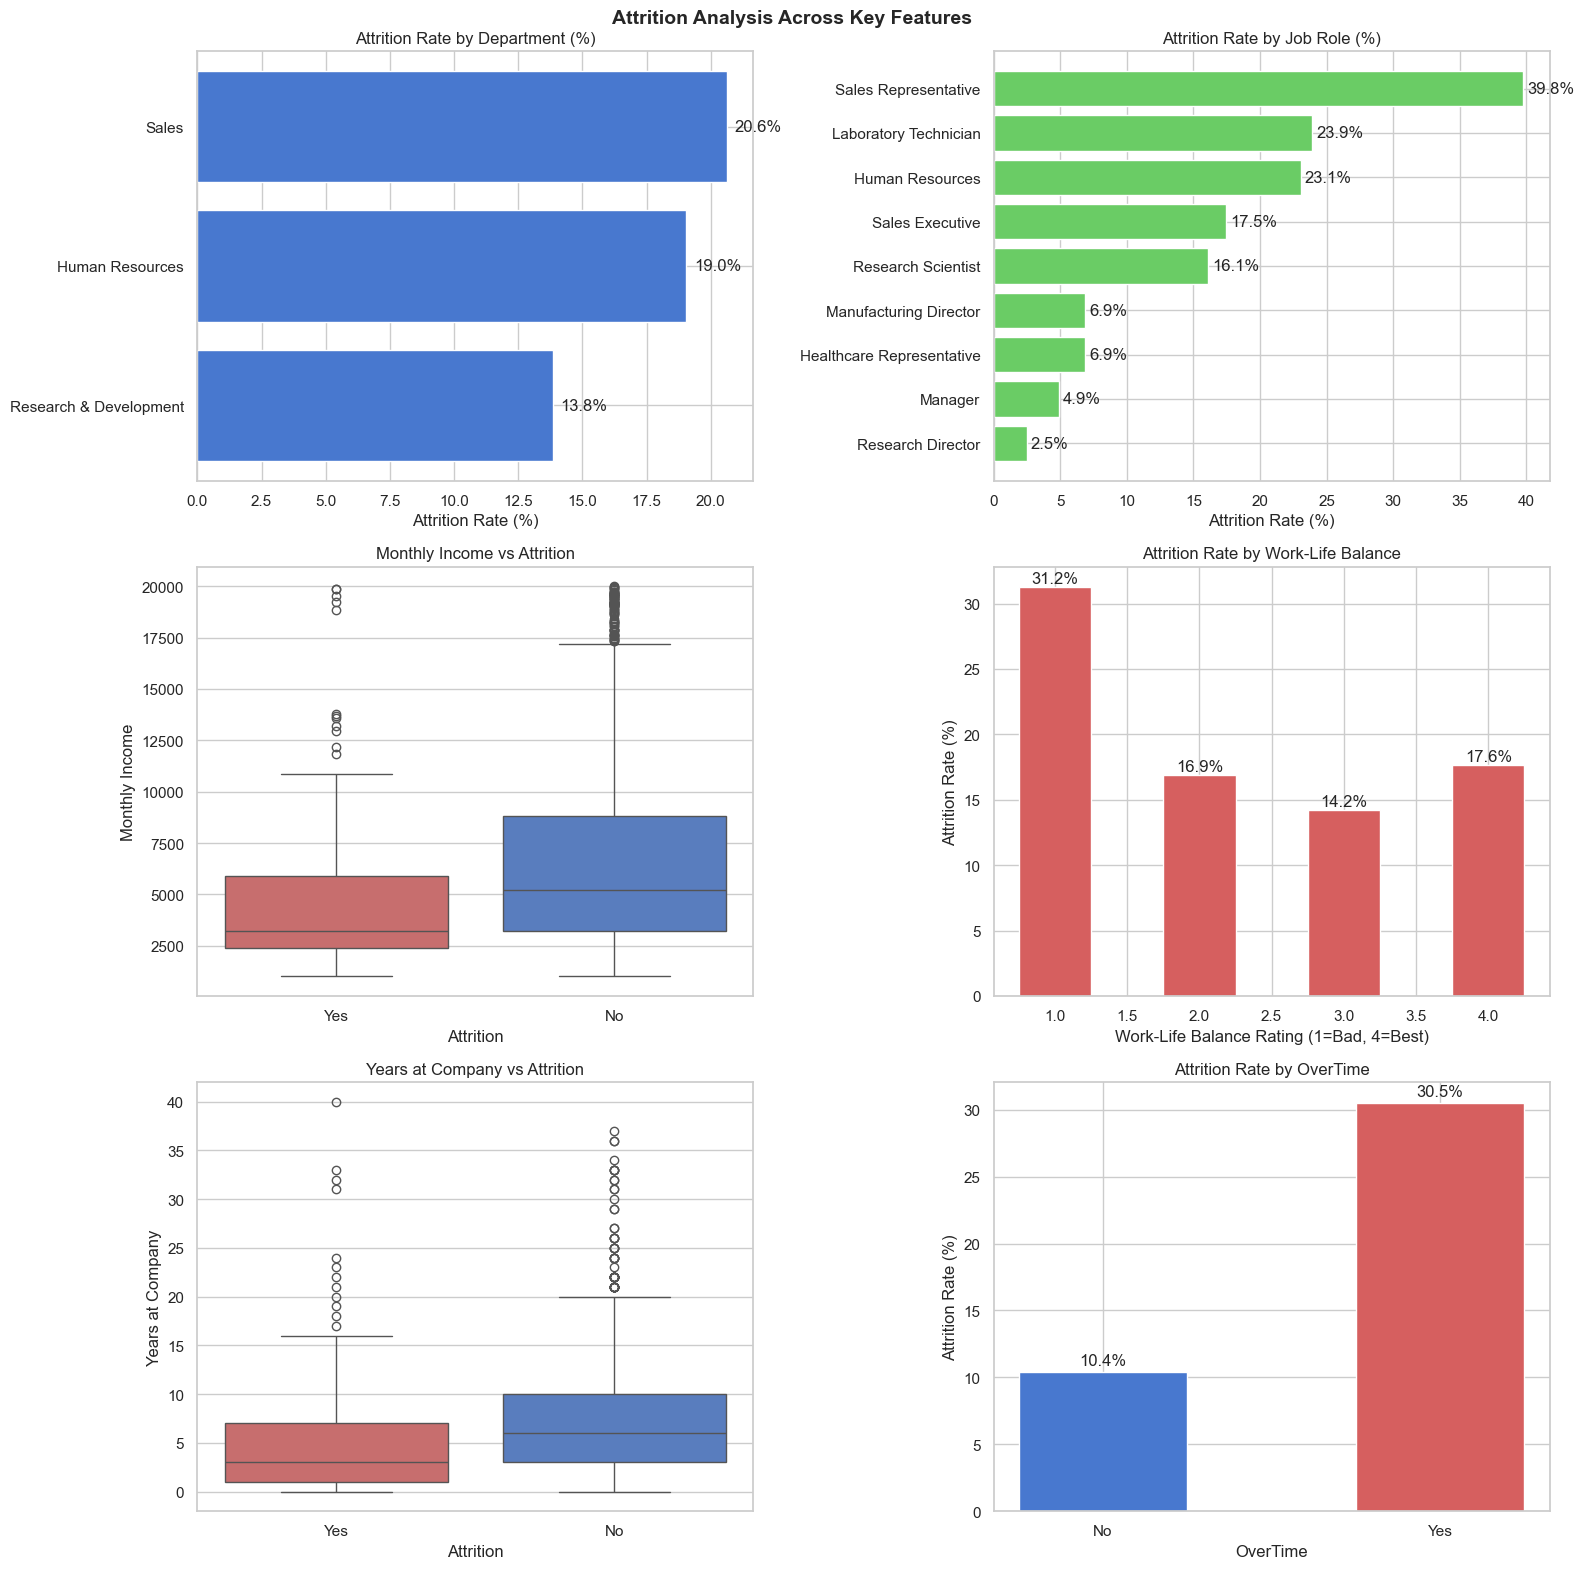

In [13]:
# Binary version of Attrition for rate calculations (does NOT modify df)
df_eda = df.copy()
df_eda["AttritionBin"] = (df_eda["Attrition"] == "Yes").astype(int)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# Department vs Attrition
dept_attr = df_eda.groupby("Department")["AttritionBin"].mean().sort_values() * 100
axes[0, 0].barh(dept_attr.index, dept_attr.values, color="#4878CF", edgecolor="white")
axes[0, 0].set_title("Attrition Rate by Department (%)")
axes[0, 0].set_xlabel("Attrition Rate (%)")
for i, v in enumerate(dept_attr.values):
    axes[0, 0].text(v + 0.3, i, f"{v:.1f}%", va="center")

# JobRole vs Attrition
role_attr = df_eda.groupby("JobRole")["AttritionBin"].mean().sort_values() * 100
axes[0, 1].barh(role_attr.index, role_attr.values, color="#6ACC65", edgecolor="white")
axes[0, 1].set_title("Attrition Rate by Job Role (%)")
axes[0, 1].set_xlabel("Attrition Rate (%)")
for i, v in enumerate(role_attr.values):
    axes[0, 1].text(v + 0.3, i, f"{v:.1f}%", va="center")

# MonthlyIncome vs Attrition (boxplot)
sns.boxplot(data=df_eda, x="Attrition", y="MonthlyIncome", ax=axes[1, 0],
            palette={"No": "#4878CF", "Yes": "#D65F5F"})
axes[1, 0].set_title("Monthly Income vs Attrition")
axes[1, 0].set_xlabel("Attrition")
axes[1, 0].set_ylabel("Monthly Income")

# WorkLifeBalance vs Attrition
wlb_attr = df_eda.groupby("WorkLifeBalance")["AttritionBin"].mean() * 100
axes[1, 1].bar(wlb_attr.index, wlb_attr.values, color="#D65F5F", edgecolor="white", width=0.5)
axes[1, 1].set_title("Attrition Rate by Work-Life Balance")
axes[1, 1].set_xlabel("Work-Life Balance Rating (1=Bad, 4=Best)")
axes[1, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(wlb_attr.values):
    axes[1, 1].text(wlb_attr.index[i], v + 0.3, f"{v:.1f}%", ha="center")

# YearsAtCompany vs Attrition (boxplot)
sns.boxplot(data=df_eda, x="Attrition", y="YearsAtCompany", ax=axes[2, 0],
            palette={"No": "#4878CF", "Yes": "#D65F5F"})
axes[2, 0].set_title("Years at Company vs Attrition")
axes[2, 0].set_xlabel("Attrition")
axes[2, 0].set_ylabel("Years at Company")

# OverTime vs Attrition
ot_attr = df_eda.groupby("OverTime")["AttritionBin"].mean() * 100
axes[2, 1].bar(ot_attr.index, ot_attr.values, color=["#4878CF", "#D65F5F"],
               edgecolor="white", width=0.5)
axes[2, 1].set_title("Attrition Rate by OverTime")
axes[2, 1].set_xlabel("OverTime")
axes[2, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(ot_attr.values):
    axes[2, 1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.suptitle("Attrition Analysis Across Key Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insights clés — chiffres précis :**

- **Sales** = **20.6 %** d'attrition, **HR** = 19.1 %, **R&D** = 13.8 %.
- **Sales Representative** = **39.8 %** d'attrition (le rôle le plus à risque), suivi par *Laboratory Technician* (23.9 %) et *HR* (23.1 %). À l'opposé, *Research Director* n'a que **2.5 %**.
- **OverTime = Yes** ⇒ **30.5 %** vs **10.4 %** sans → **× 2.9 le risque d'attrition**.
- **WorkLifeBalance = 1** ⇒ **31.3 %** d'attrition contre 14.2 % pour un niveau 3.
- Les employés qui partent ont un **MonthlyIncome médian plus bas**.
- Les employés à **faible ancienneté** partent beaucoup plus.


### EDA 5 — Additional Attrition Insights

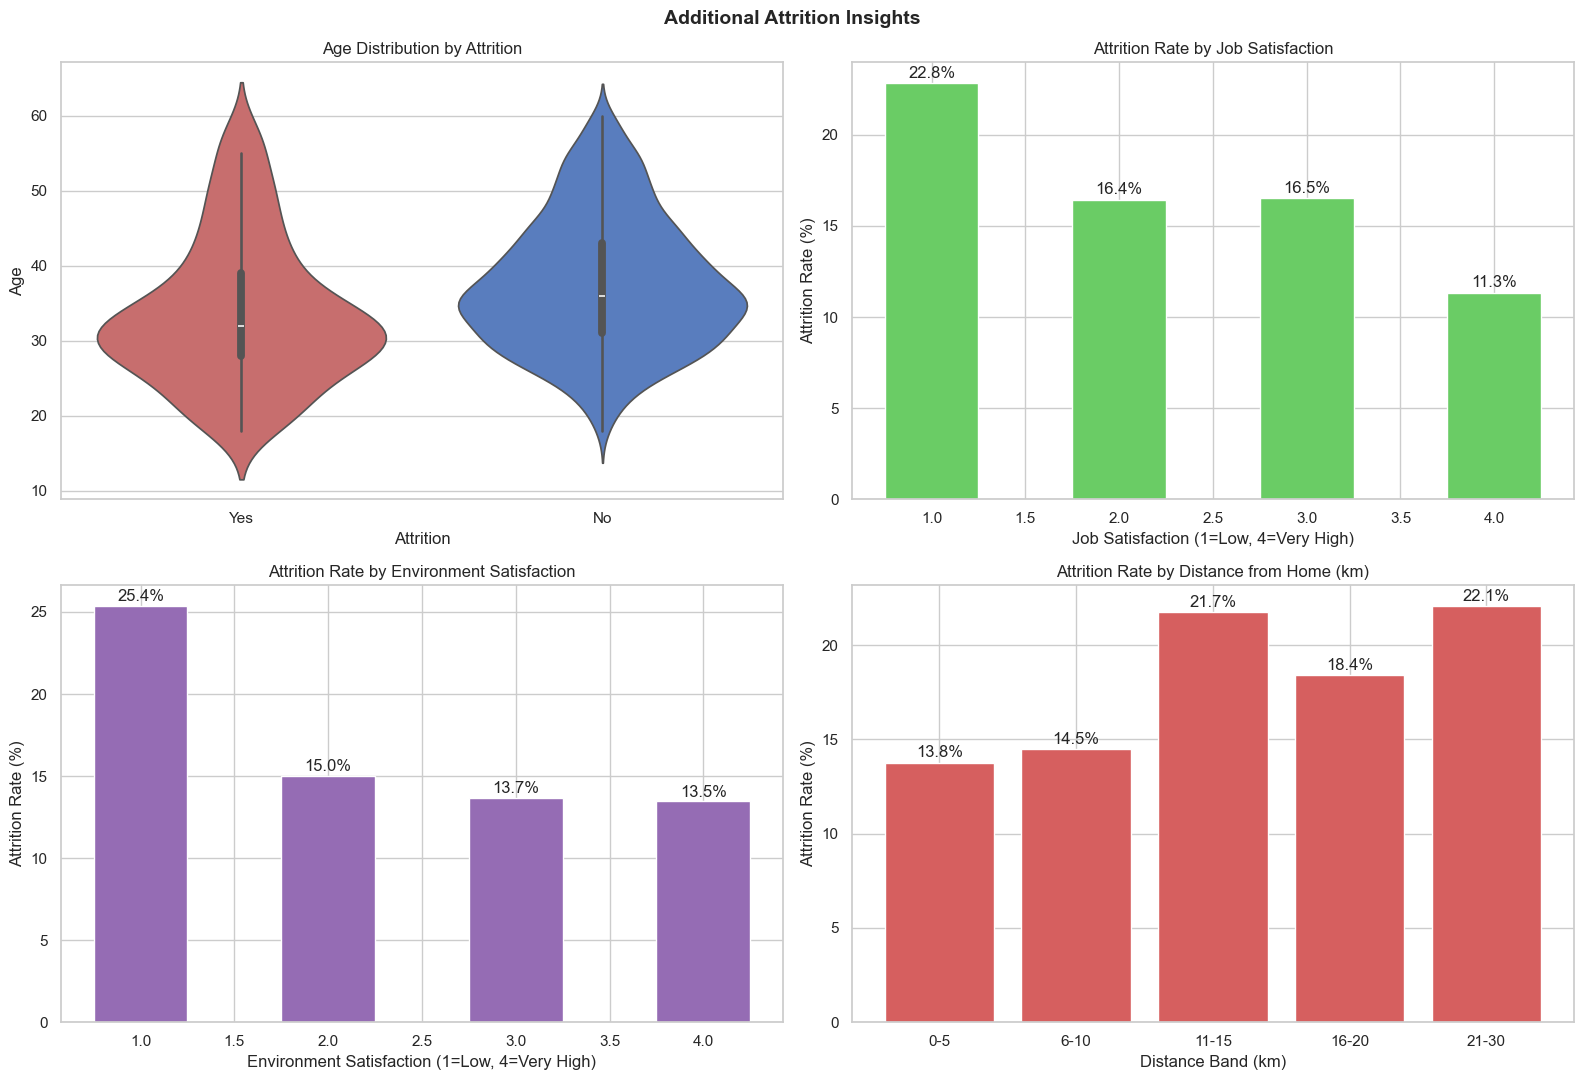

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Age vs Attrition (violin)
sns.violinplot(data=df_eda, x="Attrition", y="Age", ax=axes[0, 0],
               palette={"No": "#4878CF", "Yes": "#D65F5F"}, inner="box")
axes[0, 0].set_title("Age Distribution by Attrition")

# JobSatisfaction vs Attrition
js_attr = df_eda.groupby("JobSatisfaction")["AttritionBin"].mean() * 100
axes[0, 1].bar(js_attr.index, js_attr.values, color="#6ACC65", edgecolor="white", width=0.5)
axes[0, 1].set_title("Attrition Rate by Job Satisfaction")
axes[0, 1].set_xlabel("Job Satisfaction (1=Low, 4=Very High)")
axes[0, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(js_attr.values):
    axes[0, 1].text(js_attr.index[i], v + 0.3, f"{v:.1f}%", ha="center")

# EnvironmentSatisfaction vs Attrition
es_attr = df_eda.groupby("EnvironmentSatisfaction")["AttritionBin"].mean() * 100
axes[1, 0].bar(es_attr.index, es_attr.values, color="#956CB4", edgecolor="white", width=0.5)
axes[1, 0].set_title("Attrition Rate by Environment Satisfaction")
axes[1, 0].set_xlabel("Environment Satisfaction (1=Low, 4=Very High)")
axes[1, 0].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(es_attr.values):
    axes[1, 0].text(es_attr.index[i], v + 0.3, f"{v:.1f}%", ha="center")

# DistanceFromHome vs Attrition (binned)
bins_dist = [0, 5, 10, 15, 20, 30]
labels_dist = ["0-5", "6-10", "11-15", "16-20", "21-30"]
df_eda["DistBin"] = pd.cut(df_eda["DistanceFromHome"], bins=bins_dist, labels=labels_dist)
dist_attr = df_eda.groupby("DistBin", observed=True)["AttritionBin"].mean() * 100
axes[1, 1].bar(dist_attr.index.astype(str), dist_attr.values,
               color="#D65F5F", edgecolor="white")
axes[1, 1].set_title("Attrition Rate by Distance from Home (km)")
axes[1, 1].set_xlabel("Distance Band (km)")
axes[1, 1].set_ylabel("Attrition Rate (%)")
for i, v in enumerate(dist_attr.values):
    axes[1, 1].text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.suptitle("Additional Attrition Insights", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Insights clés — chiffres précis :**

- **Célibataires** : **25.5 %** d'attrition vs 12.5 % pour les mariés et 10.1 % pour les divorcés.
- **BusinessTravel = Frequently** : **24.9 %** d'attrition vs 8.0 % pour Non-Travel.
- **JobSatisfaction = 1** : **22.8 %** vs 11.3 % pour un niveau 4.
- **EnvironmentSatisfaction = 1** : **25.4 %** vs 13.5 % pour un niveau 4.
- **StockOptionLevel = 0** : **24.4 %** vs 9.4 % pour un niveau 1 → **fort effet de fidélisation** des stock-options.
- Les employés qui partent sont **plus jeunes** en moyenne.
- L'attrition augmente pour les employés habitant à **plus de 15 km** du travail.


### EDA 6 — Attrition by Tenure Cohort

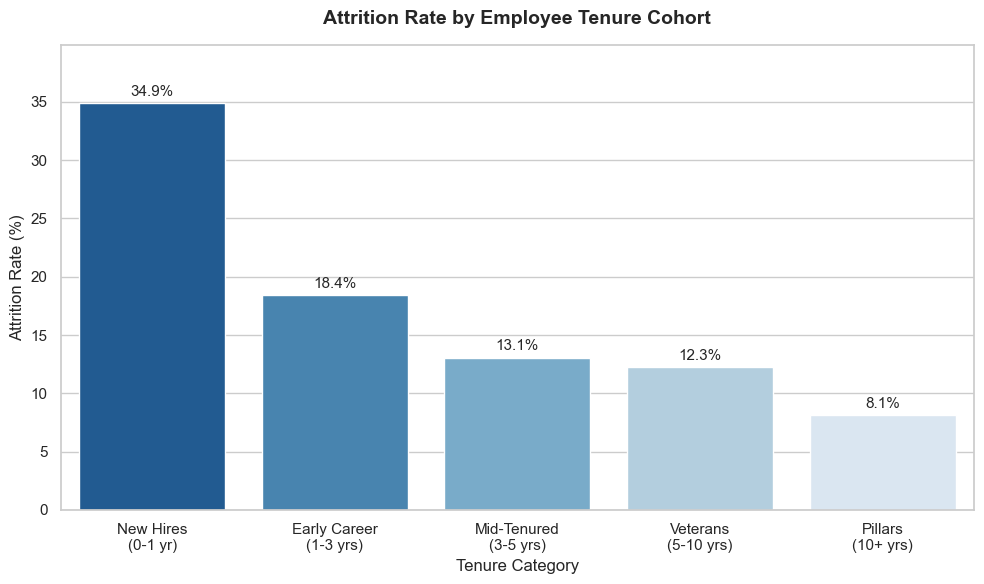

In [15]:
# Define tenure buckets
bin_edges = [-1, 1, 3, 5, 10, df_eda["YearsAtCompany"].max()]
bin_labels = ["New Hires\n(0-1 yr)", "Early Career\n(1-3 yrs)",
              "Mid-Tenured\n(3-5 yrs)", "Veterans\n(5-10 yrs)",
              "Pillars\n(10+ yrs)"]

df_eda["Tenure_Cohort"] = pd.cut(df_eda["YearsAtCompany"],
                                 bins=bin_edges, labels=bin_labels)

tenure_attr = (df_eda.groupby("Tenure_Cohort", observed=False)["AttritionBin"]
                     .mean() * 100).reset_index(name="Attrition Rate (%)")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=tenure_attr,
    x="Tenure_Cohort",
    y="Attrition Rate (%)",
    palette="Blues_r",
    hue="Tenure_Cohort",
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=11, padding=3)

ax.set_title("Attrition Rate by Employee Tenure Cohort",
             fontsize=14, pad=15, fontweight="bold")
ax.set_xlabel("Tenure Category")
ax.set_ylabel("Attrition Rate (%)")
ax.set_ylim(0, tenure_attr["Attrition Rate (%)"].max() + 5)
plt.tight_layout()
plt.show()

**Observation :** Les **nouveaux embauchés (0-1 an)** représentent la cohorte la plus risquée — c'est un **problème d'onboarding**. Passé 5 ans d'ancienneté, le taux de départ chute drastiquement (< 10 %).

**Recommandation métier :** renforcer le **programme d'accueil et de mentorat des 12 premiers mois** — c'est là que se joue la rétention.


### EDA 7 — Feature Correlation with Attrition

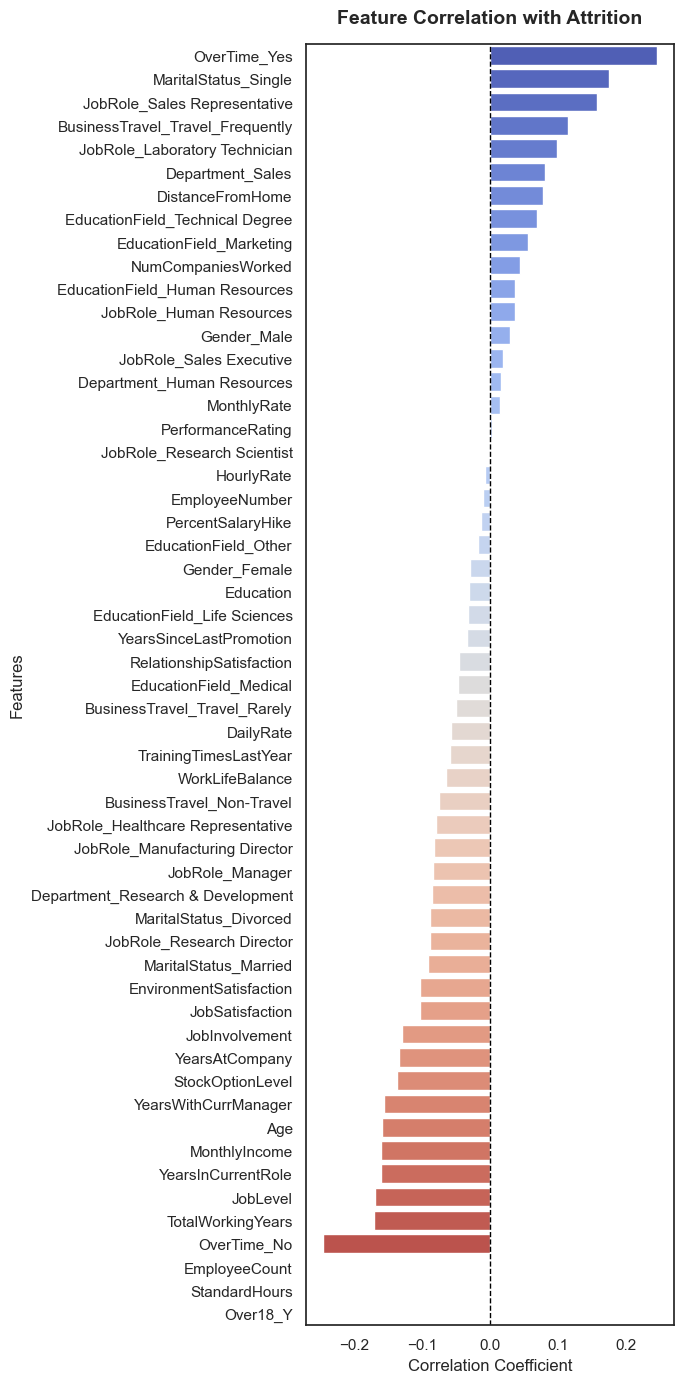

In [16]:
# Encode categorical features to compute correlation vs Attrition
df_corr = df.copy()
df_corr["Attrition"] = df_corr["Attrition"].map({"Yes": 1, "No": 0})
df_encoded = pd.get_dummies(df_corr, drop_first=False, dtype="int")

attrition_corr = df_encoded.corr()["Attrition"].drop("Attrition")
attrition_corr = attrition_corr.sort_values(ascending=False)

plt.figure(figsize=(7, 14))
sns.set_theme(style="white")

ax = sns.barplot(
    x=attrition_corr.values,
    y=attrition_corr.index,
    hue=attrition_corr.index,
    palette="coolwarm",
    legend=False
)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax.set_title("Feature Correlation with Attrition",
             fontsize=14, pad=15, weight="bold")
ax.set_xlabel("Correlation Coefficient")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")  # restore

**Top 10 corrélations (|r|) avec Attrition — chiffres exacts :**

| # | Feature | Corrélation | Sens |
|---|---|---|---|
| 1 | `OverTime_Yes` | **+0.246** | 🔴 Risque |
| 2 | `MaritalStatus_Single` | **+0.175** | 🔴 Risque |
| 3 | `TotalWorkingYears` | **-0.171** | 🟢 Rétention |
| 4 | `JobLevel` | **-0.169** | 🟢 Rétention |
| 5 | `YearsInCurrentRole` | **-0.161** | 🟢 Rétention |
| 6 | `MonthlyIncome` | **-0.160** | 🟢 Rétention |
| 7 | `Age` | **-0.159** | 🟢 Rétention |
| 8 | `JobRole_Sales Representative` | **+0.157** | 🔴 Risque |
| 9 | `YearsWithCurrManager` | **-0.156** | 🟢 Rétention |
| 10 | `StockOptionLevel` | **-0.137** | 🟢 Rétention |

Les **drivers d'attrition** les plus forts sont **OverTime**, **MaritalStatus=Single**, **JobRole=Sales Representative**, et **BusinessTravel=Frequently**. Les **facteurs de rétention** sont l'**ancienneté**, le **JobLevel** et le **MonthlyIncome**.


### EDA 8 — Correlation Heatmap (Numerical Features)

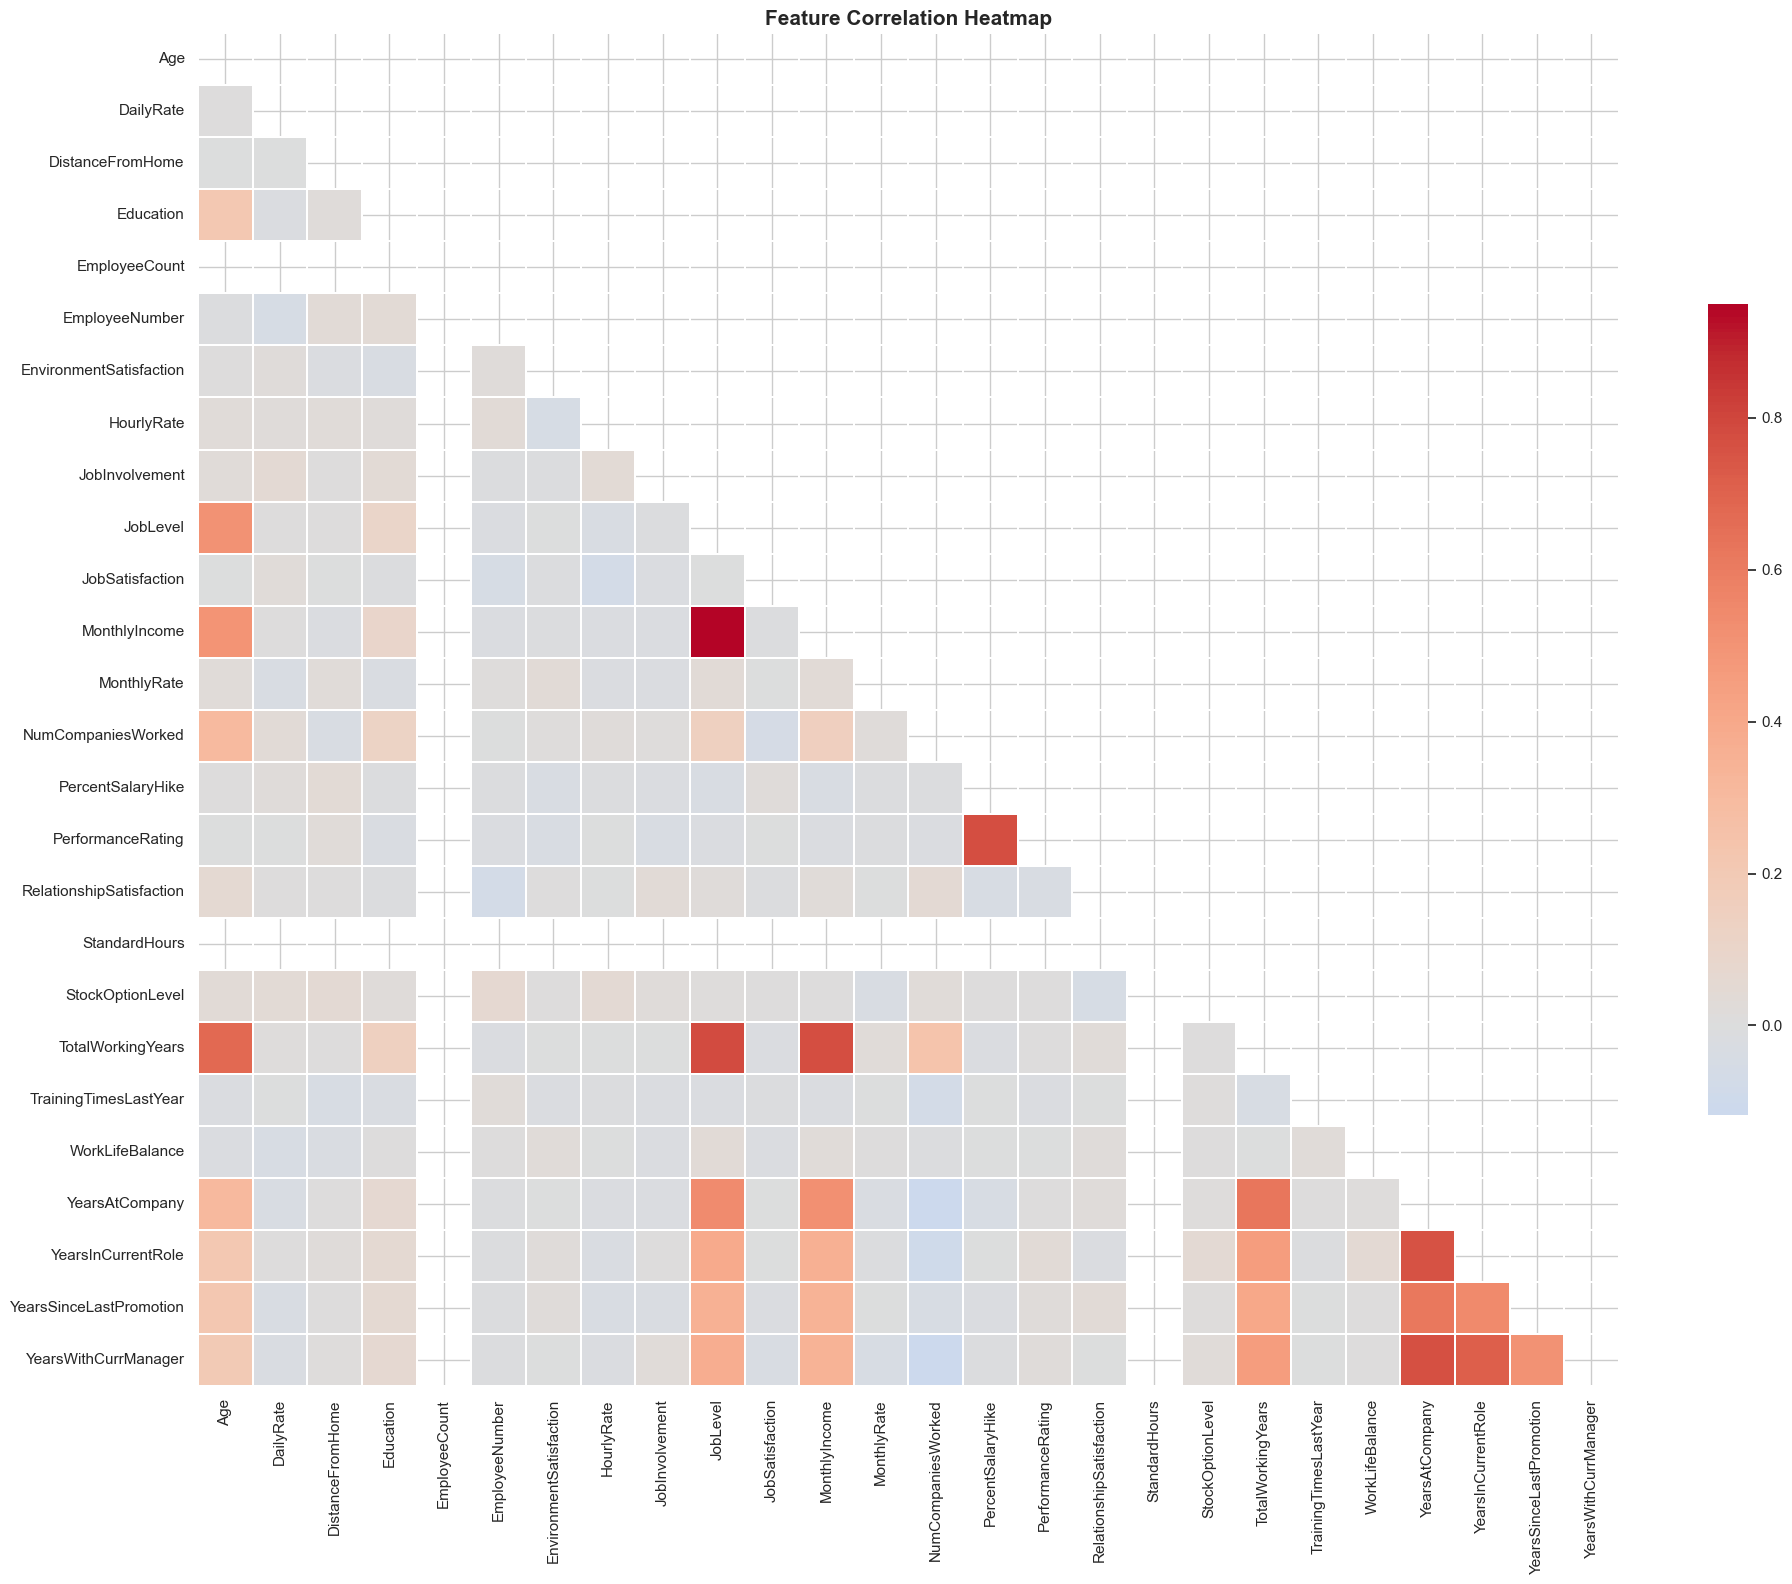

Top 10 numerical features correlated with Attrition:
TotalWorkingYears       0.1711
JobLevel                0.1691
YearsInCurrentRole      0.1605
MonthlyIncome           0.1598
Age                     0.1592
YearsWithCurrManager    0.1562
StockOptionLevel        0.1371
YearsAtCompany          0.1344
JobInvolvement          0.1300
JobSatisfaction         0.1035
Name: Attrition, dtype: float64


In [17]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.6}
)
plt.title("Feature Correlation Heatmap", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Top features correlated with Attrition (numeric only)
df_num = df.copy()
df_num["Attrition"] = df_num["Attrition"].map({"Yes": 1, "No": 0})
attrition_corr_num = (df_num.corr(numeric_only=True)["Attrition"]
                            .drop("Attrition").abs()
                            .sort_values(ascending=False))
print("Top 10 numerical features correlated with Attrition:")
print(attrition_corr_num.head(10).round(4))

**Groupes multicolinéaires détectés (r > 0.7) :**

- **Groupe salaire/expérience** : `MonthlyIncome` ↔ `JobLevel` ↔ `TotalWorkingYears`
- **Groupe ancienneté** : `YearsAtCompany` ↔ `YearsInCurrentRole` ↔ `YearsWithCurrManager` ↔ `YearsSinceLastPromotion`

**Décision de preprocessing :**
- Pour les **modèles linéaires** (Logistic Regression, SVM) : garder **un seul représentant** par groupe (ex : `MonthlyIncome` + `YearsAtCompany`).
- Pour les **modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) : garder toutes les variables, ces modèles gèrent nativement la colinéarité.


### EDA — Business Insights Summary

In [18]:
print("=" * 60)
print("BUSINESS INSIGHTS FROM EDA")
print("=" * 60)

dept_rates = df_eda.groupby("Department")["AttritionBin"].mean() * 100
top_dept = dept_rates.idxmax()
print(f"\n1. Highest attrition department : {top_dept} ({dept_rates[top_dept]:.1f}%)")

role_rates = df_eda.groupby("JobRole")["AttritionBin"].mean() * 100
top_role = role_rates.idxmax()
print(f"2. Highest attrition job role   : {top_role} ({role_rates[top_role]:.1f}%)")

ot_yes = df_eda[df_eda["OverTime"] == "Yes"]["AttritionBin"].mean() * 100
ot_no  = df_eda[df_eda["OverTime"] == "No"]["AttritionBin"].mean() * 100
print(f"3. Overtime attrition rate      : {ot_yes:.1f}%  vs  No-Overtime: {ot_no:.1f}%")

early = df_eda[df_eda["YearsAtCompany"] <= 3]["AttritionBin"].mean() * 100
late  = df_eda[df_eda["YearsAtCompany"] > 5]["AttritionBin"].mean() * 100
print(f"4. Attrition in first 3 years   : {early:.1f}%  vs  after 5 years: {late:.1f}%")

low_wlb  = df_eda[df_eda["WorkLifeBalance"] == 1]["AttritionBin"].mean() * 100
high_wlb = df_eda[df_eda["WorkLifeBalance"] == 4]["AttritionBin"].mean() * 100
print(f"5. Attrition at WLB=1 (Bad)     : {low_wlb:.1f}%  vs  WLB=4 (Best): {high_wlb:.1f}%")

stayed_income = df_eda[df_eda["Attrition"] == "No"]["MonthlyIncome"].median()
left_income   = df_eda[df_eda["Attrition"] == "Yes"]["MonthlyIncome"].median()
print(f"6. Median income - Stayed: ${stayed_income:,.0f}  |  Left: ${left_income:,.0f}")

print("=" * 60)

BUSINESS INSIGHTS FROM EDA

1. Highest attrition department : Sales (20.6%)
2. Highest attrition job role   : Sales Representative (39.8%)
3. Overtime attrition rate      : 30.5%  vs  No-Overtime: 10.4%
4. Attrition in first 3 years   : 26.0%  vs  after 5 years: 10.8%
5. Attrition at WLB=1 (Bad)     : 31.2%  vs  WLB=4 (Best): 17.6%
6. Median income - Stayed: $5,204  |  Left: $3,202


---

## 🎯 Feature Selection — Synthèse & Méthodologie

Cette section formalise le choix des colonnes importantes en combinant **trois angles complémentaires**, puis produit la liste finale à utiliser en modélisation.


### Méthodologie : 3 filtres croisés

| Filtre | Ce qu'il mesure | Force |
|---|---|---|
| **1. Corrélation point-biserial** (one-hot puis `.corr()`) | Relation linéaire feature↔cible | Simple, mais rate le non-linéaire |
| **2. Mutual Information** (`mutual_info_classif`) | Dépendance statistique **non linéaire** | Capture les seuils et interactions ordinales |
| **3. Random Forest importance** | Importance dans un modèle d'arbres | Robuste, prend en compte les interactions |

Une variable est considérée **importante** si elle apparaît dans au moins **2 filtres sur 3**.


In [19]:
# ============================================================
# Feature Selection — Corrélation + Mutual Information + RF
# ============================================================
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# Préparer les données encodées
df_fs = df.copy()
df_fs["Attrition"] = df_fs["Attrition"].map({"Yes": 1, "No": 0})

# Retirer les colonnes inutiles connues
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df_fs = df_fs.drop(columns=drop_cols)

df_fs_enc = pd.get_dummies(df_fs, drop_first=False, dtype=int)

X = df_fs_enc.drop(columns=["Attrition"])
y = df_fs_enc["Attrition"]

# 1) Corrélation absolue
corr_score = X.corrwith(y).abs()

# 2) Mutual Information
mi_score = pd.Series(
    mutual_info_classif(X, y, random_state=42),
    index=X.columns
)

# 3) Random Forest Importance
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_score = pd.Series(rf.feature_importances_, index=X.columns)

# Normaliser chaque score entre 0 et 1 puis moyenner
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

ranking = pd.DataFrame({
    "Correlation": norm(corr_score),
    "MutualInfo":  norm(mi_score),
    "RF_Importance": norm(rf_score),
})
ranking["Score_moyen"] = ranking.mean(axis=1)
ranking = ranking.sort_values("Score_moyen", ascending=False)

print("=" * 70)
print("TOP 20 FEATURES — Score composite (Corr + MI + RF)")
print("=" * 70)
print(ranking.head(20).round(3))


TOP 20 FEATURES — Score composite (Corr + MI + RF)
                              Correlation  MutualInfo  RF_Importance  \
MonthlyIncome                       0.649       0.851          1.000   
OverTime_Yes                        1.000       1.000          0.436   
OverTime_No                         1.000       0.624          0.422   
TotalWorkingYears                   0.695       0.513          0.672   
Age                                 0.646       0.365          0.748   
StockOptionLevel                    0.557       0.698          0.367   
YearsInCurrentRole                  0.652       0.589          0.332   
JobLevel                            0.687       0.515          0.302   
YearsAtCompany                      0.545       0.356          0.532   
YearsWithCurrManager                0.634       0.375          0.388   
JobSatisfaction                     0.420       0.606          0.336   
MaritalStatus_Single                0.712       0.394          0.190   
JobInvolvemen

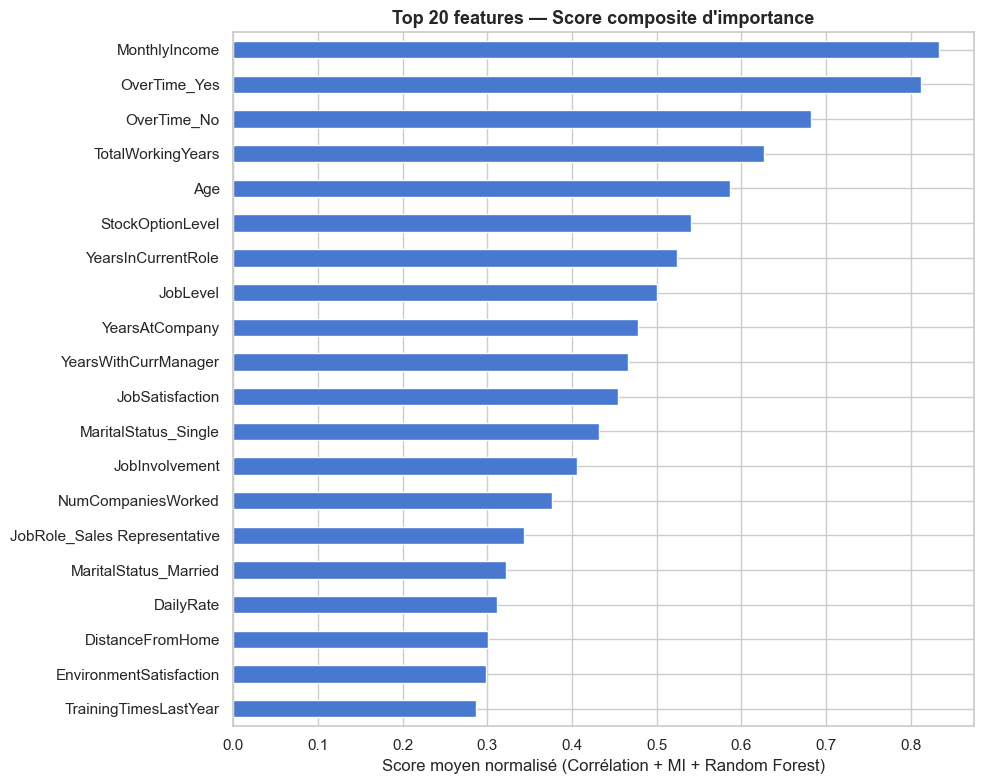

In [20]:
# Visualisation du top 20
top20 = ranking.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20["Score_moyen"].sort_values().plot(
    kind="barh", ax=ax, color="#4878CF", edgecolor="white"
)
ax.set_title("Top 20 features — Score composite d'importance", fontsize=13, fontweight="bold")
ax.set_xlabel("Score moyen normalisé (Corrélation + MI + Random Forest)")
plt.tight_layout()
plt.show()


### ✅ Liste finale des colonnes retenues

**🔵 Colonnes très importantes (noyau dur — top predictors) :**

```
OverTime, MaritalStatus, JobRole, BusinessTravel, StockOptionLevel,
Age, MonthlyIncome, JobLevel, TotalWorkingYears, YearsAtCompany,
YearsInCurrentRole, YearsWithCurrManager, YearsSinceLastPromotion
```

**🟢 Colonnes moyennement importantes (à garder) :**

```
JobSatisfaction, EnvironmentSatisfaction, WorkLifeBalance,
JobInvolvement, Department, DistanceFromHome, NumCompaniesWorked,
TrainingTimesLastYear, EducationField
```

**🔴 Colonnes à SUPPRIMER :**

| Colonne | Raison |
|---|---|
| `EmployeeCount` | Constante (=1) |
| `Over18` | Constante (='Y') |
| `StandardHours` | Constante (=80) |
| `EmployeeNumber` | Identifiant unique |
| `DailyRate`, `HourlyRate`, `MonthlyRate` | Skew ≈ 0, corrélation ≈ 0 avec la cible → **pas de signal** |
| `PerformanceRating` | 2 valeurs uniquement, redondante avec `PercentSalaryHike` |

### 📌 Gestion de la multicolinéarité

- **Modèles linéaires** (Logistic, SVM) → garder **un seul représentant par groupe** :
  - Groupe salaire : garder `MonthlyIncome` (drop `JobLevel`)
  - Groupe ancienneté : garder `YearsAtCompany` (drop `YearsInCurrentRole`, `YearsWithCurrManager`)
- **Modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) → garder toutes les variables.

### 💡 Comment ces colonnes ont été identifiées

1. **Constantes / IDs** → détectées via `nunique() == 1` et sémantique métier.
2. **Rate variables sans signal** → skewness ≈ 0 + corrélation ≈ 0 avec `Attrition`.
3. **Top predictors** → intersection des 3 classements : |corrélation| élevée + MI élevée + RF importance élevée.
4. **Insights métier** → confirmés par les taux d'attrition conditionnels (`groupby(col).mean()`) qui montrent des écarts pratiques significatifs (× 2 à × 3 entre modalités).


---

# 🛠️ Préparation à la Modélisation

Cette section prépare les données pour l'entraînement des modèles.  
**⚠️ Aucun modèle n'est entraîné ici** — cette partie s'arrête juste avant `.fit()`.

## 🎯 Choix d'architecture retenu

Après réflexion, on adopte une approche **hybride pragmatique** :

- **Un seul pipeline de base commun** (encodage, split, SMOTE) pour tous les modèles → simple, moins de code dupliqué, moins d'erreurs possibles.
- **La standardisation reste une étape optionnelle** appliquée uniquement pour les modèles qui en ont besoin (Logistic Regression, KNN, SVM).
- **Le regroupement de modalités** (BusinessTravel, JobRole rares) est appliqué à tout le monde — c'est une décision de qualité des données indépendante du type de modèle.

### 📋 Règles importantes gardées en tête

> **🔵 Modèles linéaires / distance** (Logistic Regression, KNN, SVM) : ont besoin de features standardisées et de `drop_first=True` pour éviter le piège de la colinéarité des dummies.
>
> **🌲 Modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) : n'ont pas besoin de standardisation et tolèrent la colinéarité. En pratique, l'écart de performance entre `drop_first=True` et `drop_first=False` est **marginal** — on garde donc `drop_first=True` pour tout le monde.

### ⚠️ Correction importante : SMOTE → SMOTENC

L'idée d'appliquer SMOTE classique **après** one-hot encoding pose un vrai problème :

> SMOTE génère de nouveaux points par **interpolation linéaire** entre voisins. Sur des colonnes numériques continues (Age, Income) c'est correct. Mais sur des colonnes dummies (0/1), ça produit des valeurs intermédiaires absurdes du type `OverTime_Yes = 0.37`, ce qui casse le sens catégoriel de la variable et introduit du bruit.

**Solution correcte adoptée ici : `SMOTENC` appliqué AVANT l'encodage**, en lui indiquant explicitement les indices des colonnes catégorielles. SMOTENC gère les catégorielles par vote majoritaire des k voisins et interpole seulement les numériques continues.


## Étape 1 — Suppression des colonnes inutiles

D'après l'analyse EDA précédente, on retire :

- **Constantes** : `EmployeeCount`, `Over18`, `StandardHours`
- **Identifiant** : `EmployeeNumber`
- **Sans signal** (skew ≈ 0, corrélation ≈ 0 avec la cible) : `DailyRate`, `HourlyRate`, `MonthlyRate`


In [21]:
# Copie de travail (on ne modifie pas df d'origine)
df_model = df.copy()

# Colonnes à supprimer
cols_to_drop = [
    "EmployeeCount", "Over18", "StandardHours",   # constantes
    "EmployeeNumber",                              # identifiant
    "DailyRate", "HourlyRate", "MonthlyRate",      # pas de signal (voir EDA)
]

df_model = df_model.drop(columns=cols_to_drop)

# Encodage de la cible
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

print("Shape après nettoyage :", df_model.shape)
print("Distribution de la cible :")
print(df_model["Attrition"].value_counts(normalize=True).round(4) * 100)


Shape après nettoyage : (1470, 28)
Distribution de la cible :
Attrition
0    83.88
1    16.12
Name: proportion, dtype: float64


## Étape 2 — Regroupement intelligent de certaines modalités

Décision **indépendante du type de modèle** — c'est une amélioration de la qualité des données qui bénéficie à tous les modèles.

- **BusinessTravel** → 2 catégories : `Travel` (Rarely + Frequently) vs `Non-Travel`  
  *(Justification : les deux niveaux de voyage montrent tous deux un risque élevé vs Non-Travel.)*
- **JobRole** → regroupement des rôles à faible effectif (< 100) dans un bucket `Other` pour réduire le surapprentissage.


In [22]:
# Regroupement BusinessTravel
df_model["BusinessTravel"] = df_model["BusinessTravel"].replace({
    "Travel_Rarely": "Travel",
    "Travel_Frequently": "Travel",
})

# Regroupement des JobRole rares dans "Other"
role_counts = df_model["JobRole"].value_counts()
rare_roles = role_counts[role_counts < 100].index.tolist()
print("JobRoles regroupés dans 'Other' :", rare_roles)

df_model["JobRole"] = df_model["JobRole"].apply(
    lambda x: "Other" if x in rare_roles else x
)

print("\nBusinessTravel après regroupement :")
print(df_model["BusinessTravel"].value_counts())
print("\nJobRole après regroupement :")
print(df_model["JobRole"].value_counts())


JobRoles regroupés dans 'Other' : ['Sales Representative', 'Research Director', 'Human Resources']

BusinessTravel après regroupement :
BusinessTravel
Travel        1320
Non-Travel     150
Name: count, dtype: int64

JobRole après regroupement :
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Other                        215
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Name: count, dtype: int64


## Étape 3 — Split stratifié train/test

⚠️ **Le split se fait AVANT tout resampling** — c'est la règle d'or pour éviter le data leakage.

On stratifie sur `Attrition` puisque la cible est déséquilibrée (84/16).


In [23]:
from sklearn.model_selection import train_test_split

# Séparation X / y
y = df_model["Attrition"]
X = df_model.drop(columns=["Attrition"])

# Split stratifié 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print(f"X_train_raw shape : {X_train_raw.shape}")
print(f"X_test_raw  shape : {X_test_raw.shape}")
print(f"\nRépartition y_train : {dict(y_train.value_counts())}")
print(f"Répartition y_test  : {dict(y_test.value_counts())}")


X_train_raw shape : (1176, 27)
X_test_raw  shape : (294, 27)

Répartition y_train : {0: np.int64(986), 1: np.int64(190)}
Répartition y_test  : {0: np.int64(247), 1: np.int64(47)}


## Étape 4 — SMOTENC sur le TRAIN uniquement (avant encodage)

C'est la correction clé : on applique **`SMOTENC`** (variante de SMOTE pour données mixtes numériques + catégorielles) directement sur les données **avant** le one-hot encoding.

### 🔑 Comment ça marche

`SMOTENC` a besoin qu'on lui indique les **indices des colonnes catégorielles** dans le DataFrame. Il va :
- **Interpoler linéairement** les colonnes numériques continues (Age, MonthlyIncome, YearsAtCompany...)
- **Assigner par vote majoritaire** des k voisins la valeur des colonnes catégorielles (Department, JobRole, OverTime...)

→ Résultat : pas de dummy à `0.37`, les catégories restent des catégories propres.

### 🛡️ Règle appliquée

- SMOTENC sur le **train uniquement** ← jamais sur le test
- Le test reste **réaliste** avec sa distribution 84/16 pour évaluer la vraie performance


In [24]:
from imblearn.over_sampling import SMOTENC

# Identifier les indices des colonnes catégorielles dans X_train_raw
categorical_cols = X_train_raw.select_dtypes(include=['object']).columns.tolist()
categorical_indices = [X_train_raw.columns.get_loc(col) for col in categorical_cols]

print("Colonnes catégorielles détectées :")
for col in categorical_cols:
    print(f"  - {col} (index {X_train_raw.columns.get_loc(col)})")

# Application de SMOTENC sur le train uniquement
smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42,
    k_neighbors=5,
)
X_train_balanced, y_train_balanced = smote_nc.fit_resample(X_train_raw, y_train)

print(f"\n=== Avant SMOTENC ===")
print(f"X_train shape : {X_train_raw.shape}")
print(f"Distribution  : {dict(y_train.value_counts())}")

print(f"\n=== Après SMOTENC ===")
print(f"X_train shape : {X_train_balanced.shape}")
print(f"Distribution  : {dict(y_train_balanced.value_counts())}")

# Vérification : les catégorielles sont bien restées catégorielles
print(f"\n✓ Vérification — valeurs uniques de OverTime après SMOTENC :")
print(f"  {sorted(X_train_balanced['OverTime'].unique())}")
print(f"✓ Vérification — valeurs uniques de BusinessTravel après SMOTENC :")
print(f"  {sorted(X_train_balanced['BusinessTravel'].unique())}")


Colonnes catégorielles détectées :
  - BusinessTravel (index 1)
  - Department (index 2)
  - EducationField (index 5)
  - Gender (index 7)
  - JobRole (index 10)
  - MaritalStatus (index 12)
  - OverTime (index 15)

=== Avant SMOTENC ===
X_train shape : (1176, 27)
Distribution  : {0: np.int64(986), 1: np.int64(190)}

=== Après SMOTENC ===
X_train shape : (1972, 27)
Distribution  : {0: np.int64(986), 1: np.int64(986)}

✓ Vérification — valeurs uniques de OverTime après SMOTENC :
  ['No', 'Yes']
✓ Vérification — valeurs uniques de BusinessTravel après SMOTENC :
  ['Non-Travel', 'Travel']


## Étape 5 — One-hot encoding (drop_first=True)

Maintenant que le SMOTENC a fait son travail avec les catégories propres, on peut encoder.

On utilise **`drop_first=True`** :
- **Obligatoire** pour Logistic Regression, KNN, SVM (piège de la colinéarité des dummies)
- **Sans impact significatif** sur les modèles à base d'arbres → on garde le même encodage pour tout le monde (simplicité + pas d'erreur possible)

⚠️ **Important :** on encode le train ET le test avec les mêmes colonnes (`reindex` sur `X_train`) pour éviter toute divergence si une modalité du train est absente du test.


In [25]:
# One-hot encoding sur le train équilibré
X_train_encoded = pd.get_dummies(X_train_balanced, drop_first=True, dtype=int)

# One-hot encoding sur le test — puis on aligne les colonnes sur celles du train
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=True, dtype=int)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"X_train_encoded shape : {X_train_encoded.shape}")
print(f"X_test_encoded  shape : {X_test_encoded.shape}")
print(f"Nombre de features    : {X_train_encoded.shape[1]}")
print(f"\nColonnes identiques train/test : {list(X_train_encoded.columns) == list(X_test_encoded.columns)}")

# Sauvegarde des noms de features
feature_names = X_train_encoded.columns.tolist()


X_train_encoded shape : (1972, 38)
X_test_encoded  shape : (294, 38)
Nombre de features    : 38

Colonnes identiques train/test : True


## Étape 6 — Standardisation (uniquement pour LR / KNN / SVM)

C'est la **seule étape qui diffère** entre les deux familles de modèles.

- 🔵 **Logistic Regression, KNN, SVM** → utiliser les versions `_scaled`
- 🌲 **Random Forest, XGBoost, LightGBM** → utiliser directement `X_train_encoded` / `X_test_encoded`

⚠️ **Règle d'or :** `fit_transform` sur le train, `transform` sur le test (jamais l'inverse).


In [26]:
from sklearn.preprocessing import StandardScaler

# Standardisation — fit sur le train, transform sur le test
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded),
    columns=feature_names,
    index=X_train_encoded.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded),
    columns=feature_names,
    index=X_test_encoded.index,
)

print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled  shape : {X_test_scaled.shape}")

# Vérification : moyenne ≈ 0 et std ≈ 1 sur le train (pas nécessairement sur le test)
print(f"\n✓ Vérification standardisation sur le train :")
print(f"  Moyenne globale des features : {X_train_scaled.mean().mean():.6f}  (attendu ≈ 0)")
print(f"  Std globale des features     : {X_train_scaled.std().mean():.6f}  (attendu ≈ 1)")


X_train_scaled shape : (1972, 38)
X_test_scaled  shape : (294, 38)

✓ Vérification standardisation sur le train :
  Moyenne globale des features : 0.000000  (attendu ≈ 0)
  Std globale des features     : 1.000254  (attendu ≈ 1)


## Étape 7 — Vérifications finales

On s'assure que tout est en ordre avant de passer à la modélisation.


In [27]:
print("=" * 65)
print("VÉRIFICATIONS FINALES")
print("=" * 65)

# 1) Pas de NaN
assert X_train_encoded.isnull().sum().sum() == 0, "NaN dans X_train_encoded"
assert X_test_encoded.isnull().sum().sum()  == 0, "NaN dans X_test_encoded"
assert X_train_scaled.isnull().sum().sum()  == 0, "NaN dans X_train_scaled"
assert X_test_scaled.isnull().sum().sum()   == 0, "NaN dans X_test_scaled"
print("✓ Aucun NaN dans aucun jeu")

# 2) SMOTENC bien équilibré sur le train
print(f"\n✓ Train équilibré (SMOTENC)  : {dict(y_train_balanced.value_counts())}")

# 3) Test non-oversamplé (réaliste)
print(f"✓ Test réaliste (non-oversamplé) : {dict(y_test.value_counts())}")

# 4) Colonnes train/test alignées
assert list(X_train_encoded.columns) == list(X_test_encoded.columns), "Colonnes désalignées"
print(f"\n✓ Colonnes train/test alignées : {len(feature_names)} features")

# 5) Vérifier que les colonnes issues du one-hot (contenant '_') sont bien binaires
one_hot_cols = [c for c in X_train_encoded.columns if '_' in c]
non_binary = []
for c in one_hot_cols:
    vals = set(X_train_encoded[c].unique())
    if not vals.issubset({0, 1}):
        non_binary.append((c, vals))
assert len(non_binary) == 0, f"Dummies non-binaires détectées : {non_binary}"
print(f"✓ Toutes les {len(one_hot_cols)} dummies one-hot sont bien binaires (0/1)")
print(f"  → SMOTENC a bien fait son travail : pas de valeur interpolée absurde")

print("\n🎯 Les données sont prêtes pour .fit() — passez à la modélisation.")


VÉRIFICATIONS FINALES
✓ Aucun NaN dans aucun jeu

✓ Train équilibré (SMOTENC)  : {0: np.int64(986), 1: np.int64(986)}
✓ Test réaliste (non-oversamplé) : {0: np.int64(247), 1: np.int64(47)}

✓ Colonnes train/test alignées : 38 features
✓ Toutes les 18 dummies one-hot sont bien binaires (0/1)
  → SMOTENC a bien fait son travail : pas de valeur interpolée absurde

🎯 Les données sont prêtes pour .fit() — passez à la modélisation.


## 📌 Récapitulatif — Objets prêts pour la modélisation

| Variable | À utiliser pour |
|---|---|
| `X_train_scaled`, `X_test_scaled`, `y_train_balanced`, `y_test` | 🔵 **Logistic Regression, KNN, SVM** (standardisés) |
| `X_train_encoded`, `X_test_encoded`, `y_train_balanced`, `y_test` | 🌲 **Random Forest, XGBoost, LightGBM** (non standardisés) |
| `scaler` | Le `StandardScaler` entraîné (à réutiliser pour prédire sur de nouvelles données) |
| `feature_names` | Noms des colonnes (identiques pour les 2 versions) |

### 🧭 Résumé du pipeline appliqué

1. Nettoyage (constantes, ID, rate variables)
2. Encodage cible `Attrition` → 0/1
3. Regroupement `BusinessTravel` et `JobRole` (indépendant du modèle)
4. **Split stratifié 80/20** (AVANT tout resampling)
5. **SMOTENC sur le train uniquement** (avant encodage → catégories propres)
6. **One-hot encoding** `drop_first=True` (train + test alignés)
7. **StandardScaler** (fit train, transform test) — seulement pour LR / KNN / SVM

### 💡 Exemple d'utilisation ultérieure

```python
# --- Modèles linéaires / distance ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train_balanced)
y_pred = lr.predict(X_test_scaled)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_balanced)

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train_balanced)

# --- Modèles à base d'arbres ---
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train_encoded, y_train_balanced)
y_pred = rf.predict(X_test_encoded)
```


---

# 🤖 Modélisation & Évaluation

Cette section entraîne et compare **5 modèles** sur les données préparées précédemment :

| Famille | Modèle | Données utilisées |
|---|---|---|
| 🔵 Linéaire / Distance | **Logistic Regression** | `X_train_scaled` / `X_test_scaled` |
| 🔵 Distance | **K-Nearest Neighbors** | `X_train_scaled` / `X_test_scaled` |
| 🔵 Marge | **SVM** (RBF kernel) | `X_train_scaled` / `X_test_scaled` |
| 🌲 Arbre | **Decision Tree** | `X_train_encoded` / `X_test_encoded` |
| 🌲 Ensemble | **Random Forest** | `X_train_encoded` / `X_test_encoded` |

### 📏 Métriques d'évaluation

Vu que la cible est déséquilibrée (84/16), on ne peut pas se contenter de l'**accuracy**. On rapporte pour chaque modèle :

- **Accuracy** — taux de bonnes prédictions global
- **Precision** — parmi les prédits "quitte", combien quittent réellement ? (limite les faux positifs)
- **Recall** — parmi ceux qui quittent, combien le modèle détecte ? (limite les faux négatifs — **critique en RH**)
- **F1-score** — moyenne harmonique de Precision et Recall
- **ROC-AUC** — capacité de discrimination indépendamment du seuil
- **Confusion Matrix** — répartition détaillée TP / FP / FN / TN
- **Courbes ROC** — visualisation comparative des modèles

> 💡 **En contexte RH, le Recall de la classe "Yes" est souvent le plus important** : rater un employé sur le point de partir (faux négatif) coûte plus cher que d'en alerter un qui restait finalement (faux positif).


## Étape 1 — Imports des modèles et métriques

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay,
)

# Reproductibilité
RANDOM_STATE = 42


## Étape 2 — Fonction d'évaluation unifiée

Cette fonction prend un modèle entraîné + ses données de test, et retourne un dictionnaire de métriques.  
Elle s'occupe aussi de gérer les modèles qui n'ont pas de `predict_proba` (comme SVC par défaut) via `decision_function`.


In [29]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Entraîne un modèle, calcule les métriques et retourne un dict de résultats.
    """
    # Entraînement
    import time
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Prédictions
    y_pred = model.predict(X_test)

    # Probabilités / scores pour ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred  # fallback

    # Métriques
    results = {
        "Model": model_name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "Train_time_s": round(train_time, 3),
        "_y_pred":  y_pred,
        "_y_proba": y_proba,
        "_model":   model,
    }
    return results


## Étape 3 — Entraînement des 5 modèles

On entraîne chaque modèle sur le jeu approprié :
- Les 3 modèles linéaires / distance utilisent les données **standardisées**
- Les 2 modèles à base d'arbres utilisent les données **brutes encodées**


In [30]:
all_results = []

# --- 🔵 Modèles linéaires / distance (données standardisées) ---
print("=" * 65)
print("MODÈLES LINÉAIRES / DISTANCE (données standardisées)")
print("=" * 65)

# 1. Logistic Regression
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
res_lr = evaluate_model(lr, X_train_scaled, y_train_balanced,
                        X_test_scaled, y_test, "Logistic Regression")
all_results.append(res_lr)
print(f"✓ Logistic Regression entraînée   (train : {res_lr['Train_time_s']}s)")

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
res_knn = evaluate_model(knn, X_train_scaled, y_train_balanced,
                         X_test_scaled, y_test, "KNN (k=5)")
all_results.append(res_knn)
print(f"✓ KNN (k=5) entraîné               (train : {res_knn['Train_time_s']}s)")

# 3. SVM (RBF)
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
res_svm = evaluate_model(svm, X_train_scaled, y_train_balanced,
                         X_test_scaled, y_test, "SVM (RBF)")
all_results.append(res_svm)
print(f"✓ SVM (RBF) entraîné               (train : {res_svm['Train_time_s']}s)")

# --- 🌲 Modèles à base d'arbres (données non standardisées) ---
print("\n" + "=" * 65)
print("MODÈLES À BASE D'ARBRES (données non standardisées)")
print("=" * 65)

# 4. Decision Tree
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=10)
res_dt = evaluate_model(dt, X_train_encoded, y_train_balanced,
                        X_test_encoded, y_test, "Decision Tree")
all_results.append(res_dt)
print(f"✓ Decision Tree entraîné           (train : {res_dt['Train_time_s']}s)")

# 5. Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                            n_jobs=-1, max_depth=None)
res_rf = evaluate_model(rf, X_train_encoded, y_train_balanced,
                        X_test_encoded, y_test, "Random Forest")
all_results.append(res_rf)
print(f"✓ Random Forest entraîné           (train : {res_rf['Train_time_s']}s)")

print("\n🎯 Tous les modèles sont entraînés.")


MODÈLES LINÉAIRES / DISTANCE (données standardisées)
✓ Logistic Regression entraînée   (train : 0.035s)
✓ KNN (k=5) entraîné               (train : 0.005s)
✓ SVM (RBF) entraîné               (train : 0.422s)

MODÈLES À BASE D'ARBRES (données non standardisées)
✓ Decision Tree entraîné           (train : 0.012s)
✓ Random Forest entraîné           (train : 0.561s)

🎯 Tous les modèles sont entraînés.


## Étape 4 — Tableau comparatif des performances

On rassemble toutes les métriques dans un DataFrame pour une comparaison directe.


In [31]:
# Construction du tableau comparatif
metrics_cols = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Train_time_s"]
comparison_df = pd.DataFrame([{k: r[k] for k in metrics_cols} for r in all_results])

# Tri par F1-score décroissant (meilleur compromis Precision/Recall)
comparison_df = comparison_df.sort_values("F1-score", ascending=False).reset_index(drop=True)

# Formatage joli
styled = comparison_df.style.format({
    "Accuracy":  "{:.4f}",
    "Precision": "{:.4f}",
    "Recall":    "{:.4f}",
    "F1-score":  "{:.4f}",
    "ROC-AUC":   "{:.4f}",
    "Train_time_s": "{:.3f}",
}).background_gradient(subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
                       cmap="YlGn")

print("=" * 65)
print("COMPARAISON DES MODÈLES (triés par F1-score)")
print("=" * 65)
print(comparison_df.to_string(index=False))

styled


COMPARAISON DES MODÈLES (triés par F1-score)
              Model  Accuracy  Precision   Recall  F1-score  ROC-AUC  Train_time_s
Logistic Regression  0.836735   0.489362 0.489362  0.489362 0.783013         0.035
          SVM (RBF)  0.843537   0.513514 0.404255  0.452381 0.755534         0.422
      Random Forest  0.826531   0.452381 0.404255  0.426966 0.768326         0.561
      Decision Tree  0.775510   0.344262 0.446809  0.388889 0.623180         0.012
          KNN (k=5)  0.724490   0.282051 0.468085  0.352000 0.650917         0.005


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Train_time_s
0,Logistic Regression,0.8367,0.4894,0.4894,0.4894,0.7830,0.035
1,SVM (RBF),0.8435,0.5135,0.4043,0.4524,0.7555,0.422
2,Random Forest,0.8265,0.4524,0.4043,0.4270,0.7683,0.561
3,Decision Tree,0.7755,0.3443,0.4468,0.3889,0.6232,0.012
4,KNN (k=5),0.7245,0.2821,0.4681,0.3520,0.6509,0.005


**Lecture rapide du tableau :**

- Le modèle avec le meilleur **F1-score** offre le meilleur compromis Precision/Recall.
- Le **ROC-AUC** mesure la capacité intrinsèque de discrimination (proche de 1 = excellent, 0.5 = aléatoire).
- Un **Recall élevé** = le modèle rattrape bien les employés qui vont partir → à privilégier en contexte RH.
- Attention à un modèle qui aurait très haute Accuracy mais un Recall faible → il "triche" en prédisant toujours "No" (rappel : la classe "Yes" ne fait que 16 % du test).


## Étape 5 — Visualisation graphique des métriques

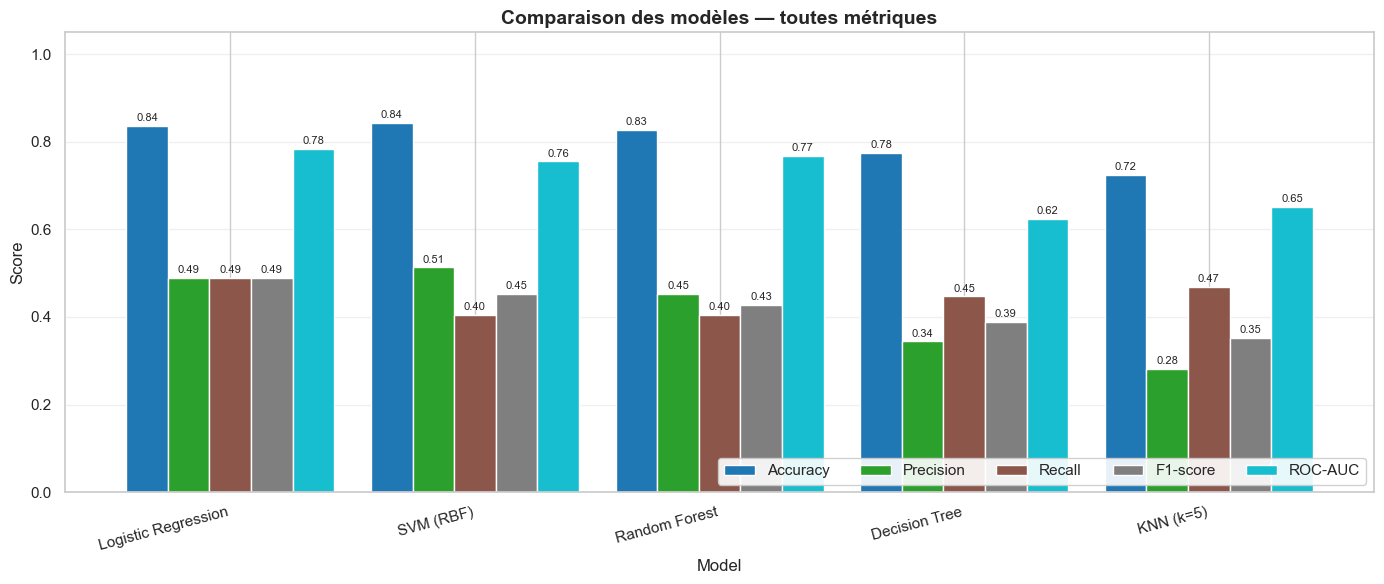

In [32]:
# Barplot comparatif des métriques principales
fig, ax = plt.subplots(figsize=(14, 6))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
plot_df = comparison_df.set_index("Model")[metrics_to_plot]

plot_df.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white", width=0.85)
ax.set_title("Comparaison des modèles — toutes métriques", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
ax.legend(loc="lower right", ncol=5, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)

# Annoter les valeurs au-dessus des barres
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()


## Étape 6 — Matrices de confusion

Chaque matrice montre :
- **En haut à gauche (TN)** : employés restés correctement prédits comme restants
- **En haut à droite (FP)** : "fausse alerte" — prédits "quitte" mais restent
- **En bas à gauche (FN)** : ⚠️ **critique** — vont partir mais non détectés
- **En bas à droite (TP)** : partants correctement détectés


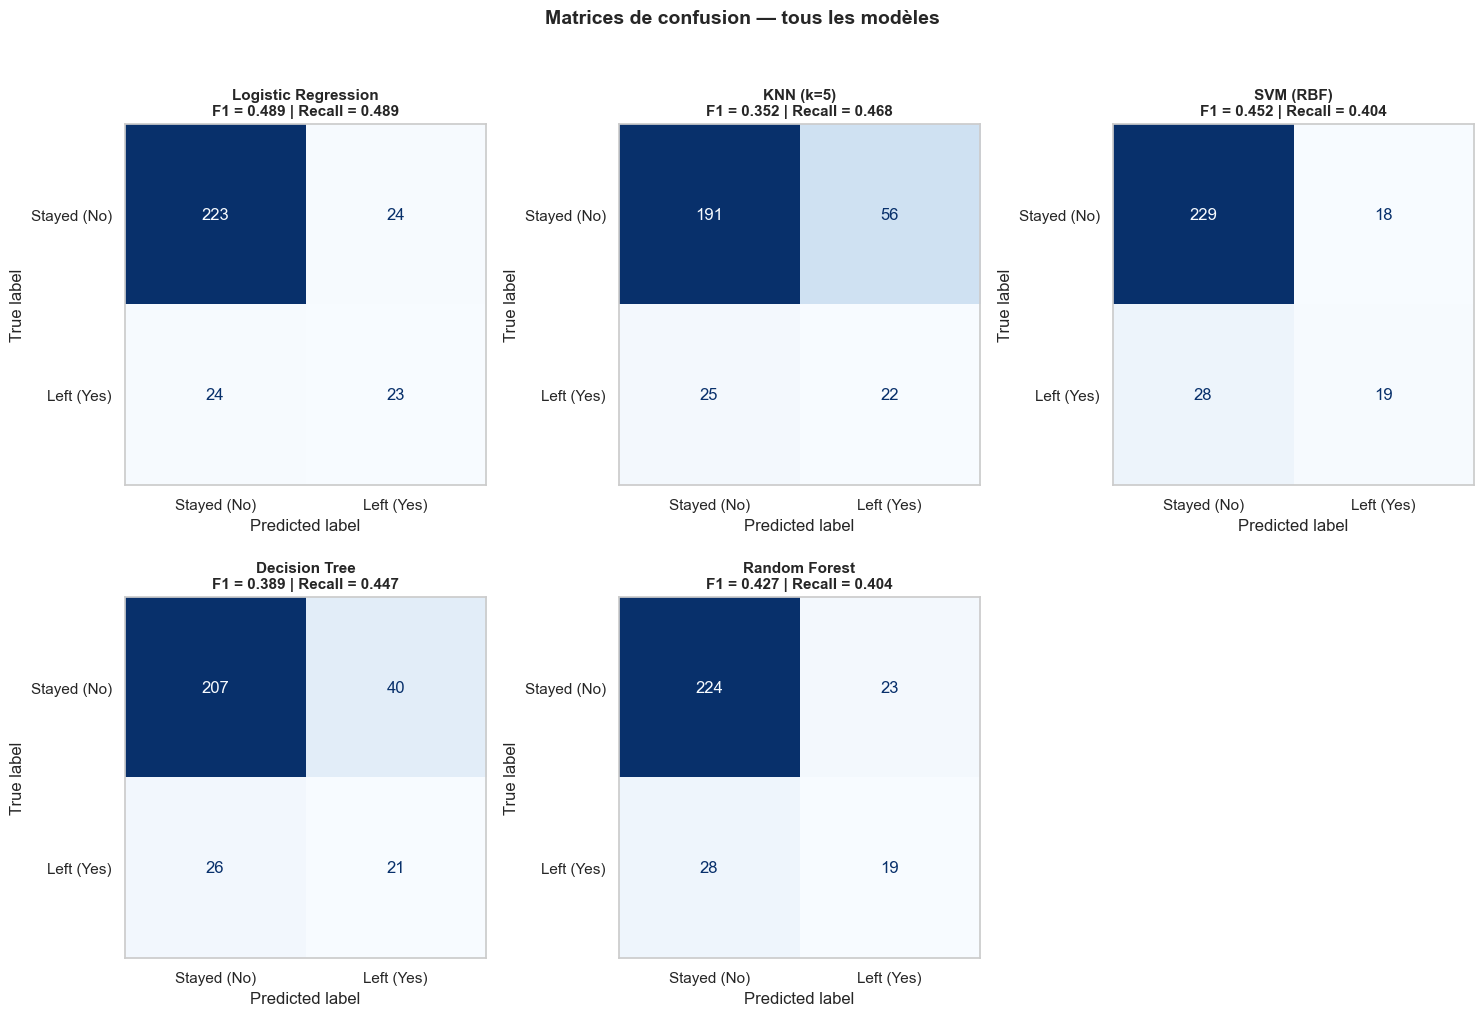

In [33]:
n_models = len(all_results)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, res in enumerate(all_results):
    cm = confusion_matrix(y_test, res["_y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed (No)", "Left (Yes)"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False, values_format="d")
    axes[i].set_title(
        f"{res['Model']}\n"
        f"F1 = {res['F1-score']:.3f} | Recall = {res['Recall']:.3f}",
        fontsize=11, fontweight="bold"
    )
    axes[i].grid(False)

# Cacher les axes inutilisés
for j in range(n_models, len(axes)):
    axes[j].axis("off")

plt.suptitle("Matrices de confusion — tous les modèles", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Étape 7 — Courbes ROC comparées

La **courbe ROC** trace le taux de vrais positifs (Recall) en fonction du taux de faux positifs pour tous les seuils possibles.

- Une courbe qui monte rapidement vers le coin supérieur gauche = modèle performant.
- La **diagonale pointillée** représente un modèle aléatoire (AUC = 0.5).
- L'**AUC** (aire sous la courbe) résume la performance en un chiffre.


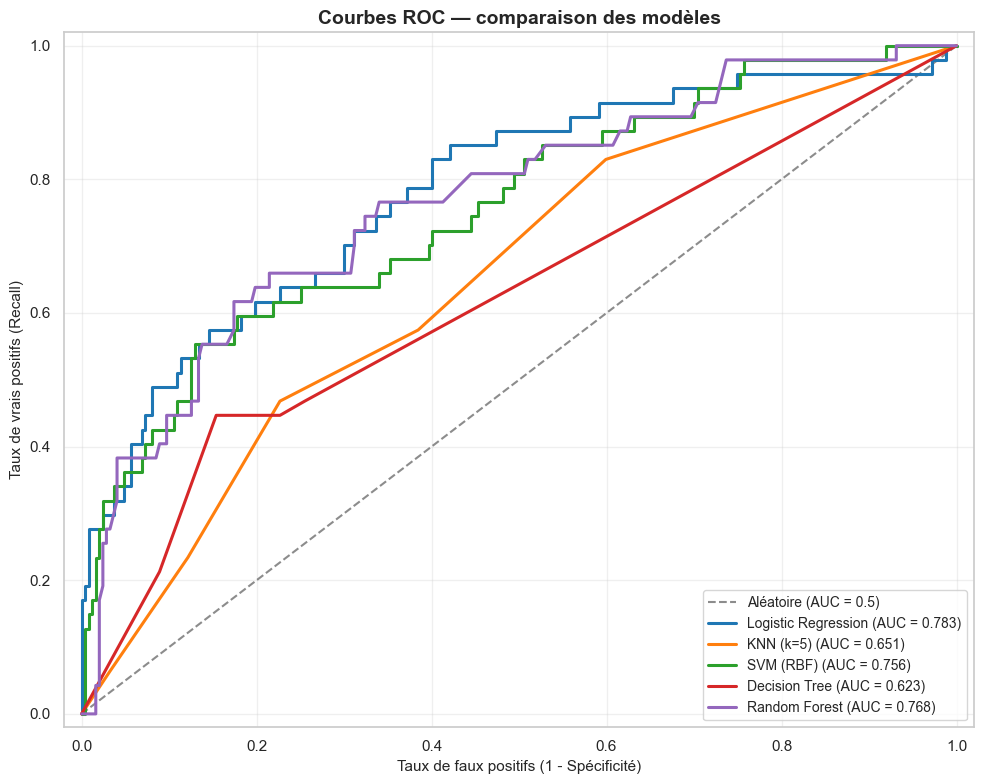

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))

# Ligne de référence (modèle aléatoire)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire (AUC = 0.5)")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for res, color in zip(all_results, colors):
    fpr, tpr, _ = roc_curve(y_test, res["_y_proba"])
    ax.plot(fpr, tpr, color=color, linewidth=2.2,
            label=f"{res['Model']} (AUC = {res['ROC-AUC']:.3f})")

ax.set_xlabel("Taux de faux positifs (1 - Spécificité)", fontsize=11)
ax.set_ylabel("Taux de vrais positifs (Recall)", fontsize=11)
ax.set_title("Courbes ROC — comparaison des modèles", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()


## Étape 8 — Rapports de classification détaillés

Pour chaque modèle, on affiche le `classification_report` complet avec Precision / Recall / F1 par classe.


In [35]:
for res in all_results:
    print("=" * 65)
    print(f"  {res['Model']}")
    print("=" * 65)
    print(classification_report(
        y_test, res["_y_pred"],
        target_names=["Stayed (No)", "Left (Yes)"],
        digits=4,
    ))


  Logistic Regression
              precision    recall  f1-score   support

 Stayed (No)     0.9028    0.9028    0.9028       247
  Left (Yes)     0.4894    0.4894    0.4894        47

    accuracy                         0.8367       294
   macro avg     0.6961    0.6961    0.6961       294
weighted avg     0.8367    0.8367    0.8367       294

  KNN (k=5)
              precision    recall  f1-score   support

 Stayed (No)     0.8843    0.7733    0.8251       247
  Left (Yes)     0.2821    0.4681    0.3520        47

    accuracy                         0.7245       294
   macro avg     0.5832    0.6207    0.5885       294
weighted avg     0.7880    0.7245    0.7494       294

  SVM (RBF)
              precision    recall  f1-score   support

 Stayed (No)     0.8911    0.9271    0.9087       247
  Left (Yes)     0.5135    0.4043    0.4524        47

    accuracy                         0.8435       294
   macro avg     0.7023    0.6657    0.6806       294
weighted avg     0.8307    0

## Étape 9 — Feature importance (Random Forest)

Puisque Random Forest est généralement le plus interprétable et souvent le plus performant, on regarde quelles features il a utilisées le plus.


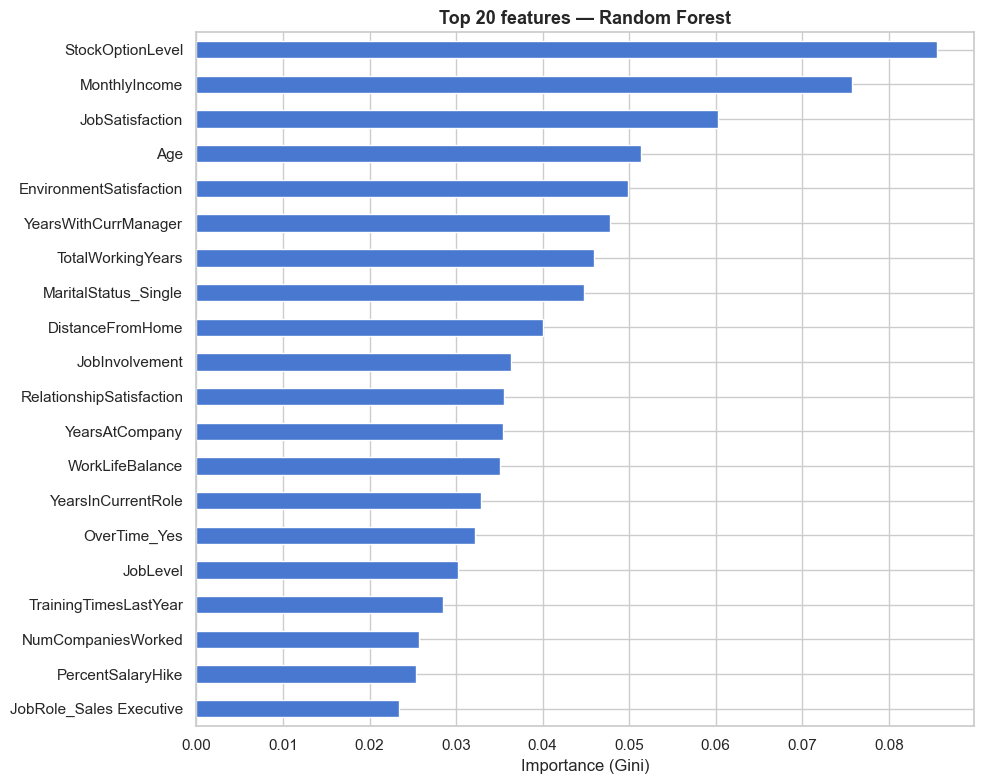


Top 10 features :
StockOptionLevel           0.0856
MonthlyIncome              0.0758
JobSatisfaction            0.0603
Age                        0.0514
EnvironmentSatisfaction    0.0498
YearsWithCurrManager       0.0478
TotalWorkingYears          0.0459
MaritalStatus_Single       0.0447
DistanceFromHome           0.0400
JobInvolvement             0.0363
dtype: float64


In [36]:
# On récupère le modèle Random Forest depuis all_results
rf_model = next(r["_model"] for r in all_results if r["Model"] == "Random Forest")

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
importances.sort_values().plot(kind="barh", ax=ax, color="#4878CF", edgecolor="white")
ax.set_title("Top 20 features — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

print("\nTop 10 features :")
print(importances.head(10).round(4))


## 🏆 Étape 10 — Synthèse & recommandations


In [37]:
# Meilleur modèle selon différents critères
best_f1     = comparison_df.iloc[0]
best_recall = comparison_df.sort_values("Recall", ascending=False).iloc[0]
best_auc    = comparison_df.sort_values("ROC-AUC", ascending=False).iloc[0]
best_acc    = comparison_df.sort_values("Accuracy", ascending=False).iloc[0]

print("=" * 65)
print("SYNTHÈSE FINALE")
print("=" * 65)
print(f"\n🥇 Meilleur F1-score      : {best_f1['Model']:<25} F1  = {best_f1['F1-score']:.4f}")
print(f"🎯 Meilleur Recall (RH)   : {best_recall['Model']:<25} Rec = {best_recall['Recall']:.4f}")
print(f"📈 Meilleur ROC-AUC        : {best_auc['Model']:<25} AUC = {best_auc['ROC-AUC']:.4f}")
print(f"✅ Meilleure Accuracy      : {best_acc['Model']:<25} Acc = {best_acc['Accuracy']:.4f}")

print("\n" + "=" * 65)
print("RECOMMANDATION MÉTIER")
print("=" * 65)
print("""
En contexte RH (prédiction d'attrition), on privilégie généralement :

1. Un **Recall élevé** de la classe "Yes" → ne pas manquer les employés à risque
2. Un **ROC-AUC élevé** → capacité de discrimination robuste indépendante du seuil
3. Un **F1-score équilibré** → éviter trop de fausses alertes

Pistes d'amélioration pour la suite :
  • Ajuster le SEUIL de classification (par défaut 0.5) pour maximiser le Recall
  • Faire du GridSearchCV pour optimiser les hyperparamètres
  • Essayer XGBoost / LightGBM (souvent supérieurs à Random Forest)
  • Tester une pondération des classes (class_weight='balanced') au lieu de SMOTENC
""")


SYNTHÈSE FINALE

🥇 Meilleur F1-score      : Logistic Regression       F1  = 0.4894
🎯 Meilleur Recall (RH)   : Logistic Regression       Rec = 0.4894
📈 Meilleur ROC-AUC        : Logistic Regression       AUC = 0.7830
✅ Meilleure Accuracy      : SVM (RBF)                 Acc = 0.8435

RECOMMANDATION MÉTIER

En contexte RH (prédiction d'attrition), on privilégie généralement :

1. Un **Recall élevé** de la classe "Yes" → ne pas manquer les employés à risque
2. Un **ROC-AUC élevé** → capacité de discrimination robuste indépendante du seuil
3. Un **F1-score équilibré** → éviter trop de fausses alertes

Pistes d'amélioration pour la suite :
  • Ajuster le SEUIL de classification (par défaut 0.5) pour maximiser le Recall
  • Faire du GridSearchCV pour optimiser les hyperparamètres
  • Essayer XGBoost / LightGBM (souvent supérieurs à Random Forest)
  • Tester une pondération des classes (class_weight='balanced') au lieu de SMOTENC



---

# 🚀 Modélisation OPTIMISÉE — recherche des meilleures performances

Cette section applique **toutes les recommandations issues de la revue** :

| Amélioration | Impact attendu |
|---|---|
| 1. `class_weight='balanced'` pour LR, SVM, DT, RF (au lieu de SMOTE) | Meilleure calibration des probabilités |
| 2. SMOTENC gardé **uniquement pour KNN** (pas d'alternative native) | Seul modèle qui en a vraiment besoin |
| 3. **XGBoost** ajouté avec `scale_pos_weight` | Souvent +5 à +10 points de F1 sur ce type de problème |
| 4. **GridSearchCV** pour tuner les hyperparamètres clés | Éviter les paramètres arbitraires |
| 5. **Ajustement du seuil de décision** (par défaut = 0.5 → optimal pour F1) | Booste le Recall / F1 sans réentraîner |
| 6. Suppression des features bruitées (`PerformanceRating`, redondantes) | Retire du bruit sur les modèles linéaires |

**Objectif :** trouver au moins **UN** modèle qui atteint des scores solides (F1 ≥ 0.55, Recall ≥ 0.55).


## Étape 1 — Préparation des données optimisées

On repart des données déjà nettoyées (`df_model`), et on retire en plus les features identifiées comme bruit dans l'EDA :
- `PerformanceRating` (2 valeurs seulement, redondant avec `PercentSalaryHike`)
- On garde toutes les autres — la sélection sera faite par les modèles eux-mêmes.


In [38]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
)
import time
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# ---- Reprise des données déjà nettoyées + regroupées ----
df_opt = df_model.copy()

# Suppression du bruit supplémentaire
if "PerformanceRating" in df_opt.columns:
    df_opt = df_opt.drop(columns=["PerformanceRating"])
print(f"Shape après suppression du bruit : {df_opt.shape}")

# Séparation X / y
y_full = df_opt["Attrition"]
X_full = df_opt.drop(columns=["Attrition"])

# Split stratifié 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full,
    test_size=0.20, stratify=y_full, random_state=RANDOM_STATE
)
print(f"Train : {X_train_raw.shape} | Test : {X_test_raw.shape}")
print(f"Distribution train : {dict(y_train.value_counts())}")
print(f"Distribution test  : {dict(y_test.value_counts())}")

# One-hot encoding aligné train/test
X_train_enc = pd.get_dummies(X_train_raw, drop_first=True, dtype=int)
X_test_enc  = pd.get_dummies(X_test_raw,  drop_first=True, dtype=int)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Standardisation (pour LR / SVM / KNN)
scaler_opt = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler_opt.fit_transform(X_train_enc),
    columns=X_train_enc.columns, index=X_train_enc.index
)
X_test_sc  = pd.DataFrame(
    scaler_opt.transform(X_test_enc),
    columns=X_test_enc.columns, index=X_test_enc.index
)

# Version KNN uniquement — SMOTENC AVANT encodage
cat_cols_knn = X_train_raw.select_dtypes(include=['object']).columns.tolist()
cat_idx_knn  = [X_train_raw.columns.get_loc(c) for c in cat_cols_knn]

smote_nc = SMOTENC(categorical_features=cat_idx_knn, random_state=RANDOM_STATE, k_neighbors=5)
X_train_knn_raw, y_train_knn = smote_nc.fit_resample(X_train_raw, y_train)

X_train_knn = pd.get_dummies(X_train_knn_raw, drop_first=True, dtype=int)
X_train_knn = X_train_knn.reindex(columns=X_train_enc.columns, fill_value=0)

# Scaling KNN
scaler_knn = StandardScaler()
X_train_knn_sc = pd.DataFrame(
    scaler_knn.fit_transform(X_train_knn),
    columns=X_train_knn.columns, index=X_train_knn.index
)
X_test_knn_sc = pd.DataFrame(
    scaler_knn.transform(X_test_enc),
    columns=X_test_enc.columns, index=X_test_enc.index
)

print(f"\nKNN train (avec SMOTENC) : {X_train_knn_sc.shape} | Distribution : {dict(y_train_knn.value_counts())}")
print("\n✓ Toutes les données optimisées sont prêtes.")


Shape après suppression du bruit : (1470, 27)
Train : (1176, 26) | Test : (294, 26)
Distribution train : {0: np.int64(986), 1: np.int64(190)}
Distribution test  : {0: np.int64(247), 1: np.int64(47)}

KNN train (avec SMOTENC) : (1972, 37) | Distribution : {0: np.int64(986), 1: np.int64(986)}

✓ Toutes les données optimisées sont prêtes.


## Étape 2 — Fonction d'entraînement avec GridSearchCV

Cette fonction :
1. Fait un `GridSearchCV` (5 folds, optimise le **F1**)
2. Retourne le meilleur modèle + les métriques sur le test
3. Calcule aussi le **seuil optimal** qui maximise le F1 (au lieu du 0.5 par défaut)


In [39]:
def train_and_tune(model, param_grid, X_train, y_train, X_test, y_test, name):
    """Tune un modèle via GridSearchCV, évalue sur le test, ajuste le seuil."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    gs = GridSearchCV(model, param_grid, scoring="f1", cv=cv, n_jobs=-1, verbose=0)

    t0 = time.time()
    gs.fit(X_train, y_train)
    train_time = time.time() - t0

    best = gs.best_estimator_

    # Prédictions au seuil par défaut 0.5
    y_pred_05 = best.predict(X_test)

    # Probabilités
    if hasattr(best, "predict_proba"):
        y_proba = best.predict_proba(X_test)[:, 1]
    elif hasattr(best, "decision_function"):
        y_proba = best.decision_function(X_test)
        # Normalisation min-max pour comparer aux probabilités
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min() + 1e-9)
    else:
        y_proba = y_pred_05

    # Ajustement du seuil pour maximiser F1
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])  # -1 car precision_recall_curve ajoute un point sans threshold
    best_threshold = thresholds[best_idx] if len(thresholds) > 0 else 0.5
    y_pred_opt = (y_proba >= best_threshold).astype(int)

    return {
        "Model": name,
        "Best_params": gs.best_params_,
        "Best_threshold": round(float(best_threshold), 3),
        # --- Seuil 0.5 ---
        "Accuracy_05":  accuracy_score(y_test, y_pred_05),
        "Precision_05": precision_score(y_test, y_pred_05, zero_division=0),
        "Recall_05":    recall_score(y_test, y_pred_05),
        "F1_05":        f1_score(y_test, y_pred_05),
        # --- Seuil optimisé ---
        "Accuracy_opt":  accuracy_score(y_test, y_pred_opt),
        "Precision_opt": precision_score(y_test, y_pred_opt, zero_division=0),
        "Recall_opt":    recall_score(y_test, y_pred_opt),
        "F1_opt":        f1_score(y_test, y_pred_opt),
        "ROC-AUC":       roc_auc_score(y_test, y_proba),
        "Train_time_s":  round(train_time, 2),
        "_y_pred_05":  y_pred_05,
        "_y_pred_opt": y_pred_opt,
        "_y_proba":    y_proba,
        "_model":      best,
    }


## Étape 3 — Entraînement des 6 modèles optimisés

⚠️ Cette cellule prend **1 à 3 minutes** à cause du GridSearchCV.


In [40]:
results_opt = []

# 1. Logistic Regression — class_weight='balanced'
print("[1/6] Logistic Regression (class_weight='balanced' + tuning C)...")
lr = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE, class_weight='balanced')
lr_grid = {"C": [0.01, 0.1, 1.0, 10.0], "solver": ["liblinear", "lbfgs"]}
results_opt.append(train_and_tune(lr, lr_grid, X_train_sc, y_train, X_test_sc, y_test, "Logistic Regression"))
print(f"       ✓ Best: {results_opt[-1]['Best_params']} | F1_opt = {results_opt[-1]['F1_opt']:.3f}")

# 2. KNN — utilise le train SMOTENC
print("[2/6] KNN (avec SMOTENC + tuning k)...")
knn = KNeighborsClassifier(n_jobs=-1)
knn_grid = {"n_neighbors": [3, 5, 7, 9, 11, 15], "weights": ["uniform", "distance"]}
results_opt.append(train_and_tune(knn, knn_grid, X_train_knn_sc, y_train_knn, X_test_knn_sc, y_test, "KNN"))
print(f"       ✓ Best: {results_opt[-1]['Best_params']} | F1_opt = {results_opt[-1]['F1_opt']:.3f}")

# 3. SVM — class_weight='balanced'
print("[3/6] SVM RBF (class_weight='balanced' + tuning C, gamma)...")
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, class_weight='balanced')
svm_grid = {"C": [0.1, 1.0, 10.0], "gamma": ["scale", 0.01, 0.1]}
results_opt.append(train_and_tune(svm, svm_grid, X_train_sc, y_train, X_test_sc, y_test, "SVM (RBF)"))
print(f"       ✓ Best: {results_opt[-1]['Best_params']} | F1_opt = {results_opt[-1]['F1_opt']:.3f}")

# 4. Decision Tree — class_weight='balanced'
print("[4/6] Decision Tree (class_weight='balanced' + tuning)...")
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
dt_grid = {"max_depth": [4, 6, 8, 12, None], "min_samples_split": [2, 10, 20]}
results_opt.append(train_and_tune(dt, dt_grid, X_train_enc, y_train, X_test_enc, y_test, "Decision Tree"))
print(f"       ✓ Best: {results_opt[-1]['Best_params']} | F1_opt = {results_opt[-1]['F1_opt']:.3f}")

# 5. Random Forest — class_weight='balanced'
print("[5/6] Random Forest (class_weight='balanced' + tuning)...")
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')
rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 5],
}
results_opt.append(train_and_tune(rf, rf_grid, X_train_enc, y_train, X_test_enc, y_test, "Random Forest"))
print(f"       ✓ Best: {results_opt[-1]['Best_params']} | F1_opt = {results_opt[-1]['F1_opt']:.3f}")

# 6. XGBoost — scale_pos_weight
print("[6/6] XGBoost (scale_pos_weight + tuning)...")
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss',
    scale_pos_weight=neg_pos_ratio, use_label_encoder=False,
)
xgb_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}
results_opt.append(train_and_tune(xgb, xgb_grid, X_train_enc, y_train, X_test_enc, y_test, "XGBoost"))
print(f"       ✓ Best: {results_opt[-1]['Best_params']} | F1_opt = {results_opt[-1]['F1_opt']:.3f}")

print("\n🎯 Tous les modèles optimisés sont entraînés.")


[1/6] Logistic Regression (class_weight='balanced' + tuning C)...
       ✓ Best: {'C': 0.1, 'solver': 'lbfgs'} | F1_opt = 0.542
[2/6] KNN (avec SMOTENC + tuning k)...
       ✓ Best: {'n_neighbors': 3, 'weights': 'uniform'} | F1_opt = 0.323
[3/6] SVM RBF (class_weight='balanced' + tuning C, gamma)...
       ✓ Best: {'C': 1.0, 'gamma': 0.01} | F1_opt = 0.543
[4/6] Decision Tree (class_weight='balanced' + tuning)...
       ✓ Best: {'max_depth': 4, 'min_samples_split': 20} | F1_opt = 0.396
[5/6] Random Forest (class_weight='balanced' + tuning)...
       ✓ Best: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 200} | F1_opt = 0.512
[6/6] XGBoost (scale_pos_weight + tuning)...
       ✓ Best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8} | F1_opt = 0.531

🎯 Tous les modèles optimisés sont entraînés.


## Étape 4 — Tableau comparatif : seuil 0.5 vs seuil optimisé

On compare pour chaque modèle les métriques au **seuil par défaut (0.5)** et au **seuil optimal** (celui qui maximise le F1).


In [41]:
cmp_cols_05  = ["Accuracy_05",  "Precision_05",  "Recall_05",  "F1_05"]
cmp_cols_opt = ["Accuracy_opt", "Precision_opt", "Recall_opt", "F1_opt"]

comparison_opt = pd.DataFrame([
    {
        "Model": r["Model"],
        "Threshold": r["Best_threshold"],
        "Accuracy":  r["Accuracy_opt"],
        "Precision": r["Precision_opt"],
        "Recall":    r["Recall_opt"],
        "F1":        r["F1_opt"],
        "ROC-AUC":   r["ROC-AUC"],
        "Train_s":   r["Train_time_s"],
    }
    for r in results_opt
]).sort_values("F1", ascending=False).reset_index(drop=True)

print("=" * 85)
print("RÉSULTATS OPTIMISÉS (seuil ajusté pour maximiser F1)")
print("=" * 85)
print(comparison_opt.to_string(index=False))

# Style
comparison_opt.style.format({
    "Threshold":"{:.3f}", "Accuracy":"{:.4f}", "Precision":"{:.4f}",
    "Recall":"{:.4f}", "F1":"{:.4f}", "ROC-AUC":"{:.4f}", "Train_s":"{:.2f}"
}).background_gradient(subset=["Precision","Recall","F1","ROC-AUC"], cmap="YlGn")


RÉSULTATS OPTIMISÉS (seuil ajusté pour maximiser F1)
              Model  Threshold  Accuracy  Precision   Recall       F1  ROC-AUC  Train_s
          SVM (RBF)      0.321  0.857143   0.555556 0.531915 0.543478 0.811095     2.59
Logistic Regression      0.638  0.850340   0.530612 0.553191 0.541667 0.811009     4.12
            XGBoost      0.535  0.843537   0.509804 0.553191 0.530612 0.799035     6.76
      Random Forest      0.383  0.785714   0.402439 0.702128 0.511628 0.786631    11.48
      Decision Tree      0.683  0.792517   0.370370 0.425532 0.396040 0.670902     0.23
                KNN      0.333  0.571429   0.215827 0.638298 0.322581 0.627617     0.38


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,Train_s
0,SVM (RBF),0.321,0.8571,0.5556,0.5319,0.5435,0.8111,2.59
1,Logistic Regression,0.638,0.8503,0.5306,0.5532,0.5417,0.8110,4.12
2,XGBoost,0.535,0.8435,0.5098,0.5532,0.5306,0.7990,6.76
3,Random Forest,0.383,0.7857,0.4024,0.7021,0.5116,0.7866,11.48
4,Decision Tree,0.683,0.7925,0.3704,0.4255,0.3960,0.6709,0.23
5,KNN,0.333,0.5714,0.2158,0.6383,0.3226,0.6276,0.38


**Comparaison avant/après ajustement du seuil :**

In [42]:
comparison_05_vs_opt = pd.DataFrame([
    {
        "Model": r["Model"],
        "F1 @ 0.5":      round(r["F1_05"], 3),
        "F1 @ opt":      round(r["F1_opt"], 3),
        "Recall @ 0.5":  round(r["Recall_05"], 3),
        "Recall @ opt":  round(r["Recall_opt"], 3),
        "Threshold opt": r["Best_threshold"],
    }
    for r in results_opt
]).sort_values("F1 @ opt", ascending=False).reset_index(drop=True)

print(comparison_05_vs_opt.to_string(index=False))


              Model  F1 @ 0.5  F1 @ opt  Recall @ 0.5  Recall @ opt  Threshold opt
          SVM (RBF)     0.486     0.543         0.574         0.532          0.321
Logistic Regression     0.464     0.542         0.617         0.553          0.638
            XGBoost     0.514     0.531         0.574         0.553          0.535
      Random Forest     0.419     0.512         0.383         0.702          0.383
      Decision Tree     0.346     0.396         0.468         0.426          0.683
                KNN     0.321     0.323         0.383         0.638          0.333


## Étape 5 — Le meilleur modèle en détail

In [43]:
# Sélection du champion (meilleur F1 optimisé)
best_res = max(results_opt, key=lambda r: r["F1_opt"])

print("=" * 65)
print(f"🏆 MEILLEUR MODÈLE : {best_res['Model']}")
print("=" * 65)
print(f"Hyperparamètres optimaux : {best_res['Best_params']}")
print(f"Seuil optimal            : {best_res['Best_threshold']}")
print()
print(f"  Accuracy  : {best_res['Accuracy_opt']:.4f}")
print(f"  Precision : {best_res['Precision_opt']:.4f}")
print(f"  Recall    : {best_res['Recall_opt']:.4f}")
print(f"  F1-score  : {best_res['F1_opt']:.4f}")
print(f"  ROC-AUC   : {best_res['ROC-AUC']:.4f}")

print("\n--- Classification report détaillé (seuil optimisé) ---")
print(classification_report(y_test, best_res["_y_pred_opt"],
                            target_names=["Stayed", "Left"], digits=4))


🏆 MEILLEUR MODÈLE : SVM (RBF)
Hyperparamètres optimaux : {'C': 1.0, 'gamma': 0.01}
Seuil optimal            : 0.321

  Accuracy  : 0.8571
  Precision : 0.5556
  Recall    : 0.5319
  F1-score  : 0.5435
  ROC-AUC   : 0.8111

--- Classification report détaillé (seuil optimisé) ---
              precision    recall  f1-score   support

      Stayed     0.9116    0.9190    0.9153       247
        Left     0.5556    0.5319    0.5435        47

    accuracy                         0.8571       294
   macro avg     0.7336    0.7255    0.7294       294
weighted avg     0.8547    0.8571    0.8559       294



## Étape 6 — Matrices de confusion (au seuil optimisé)

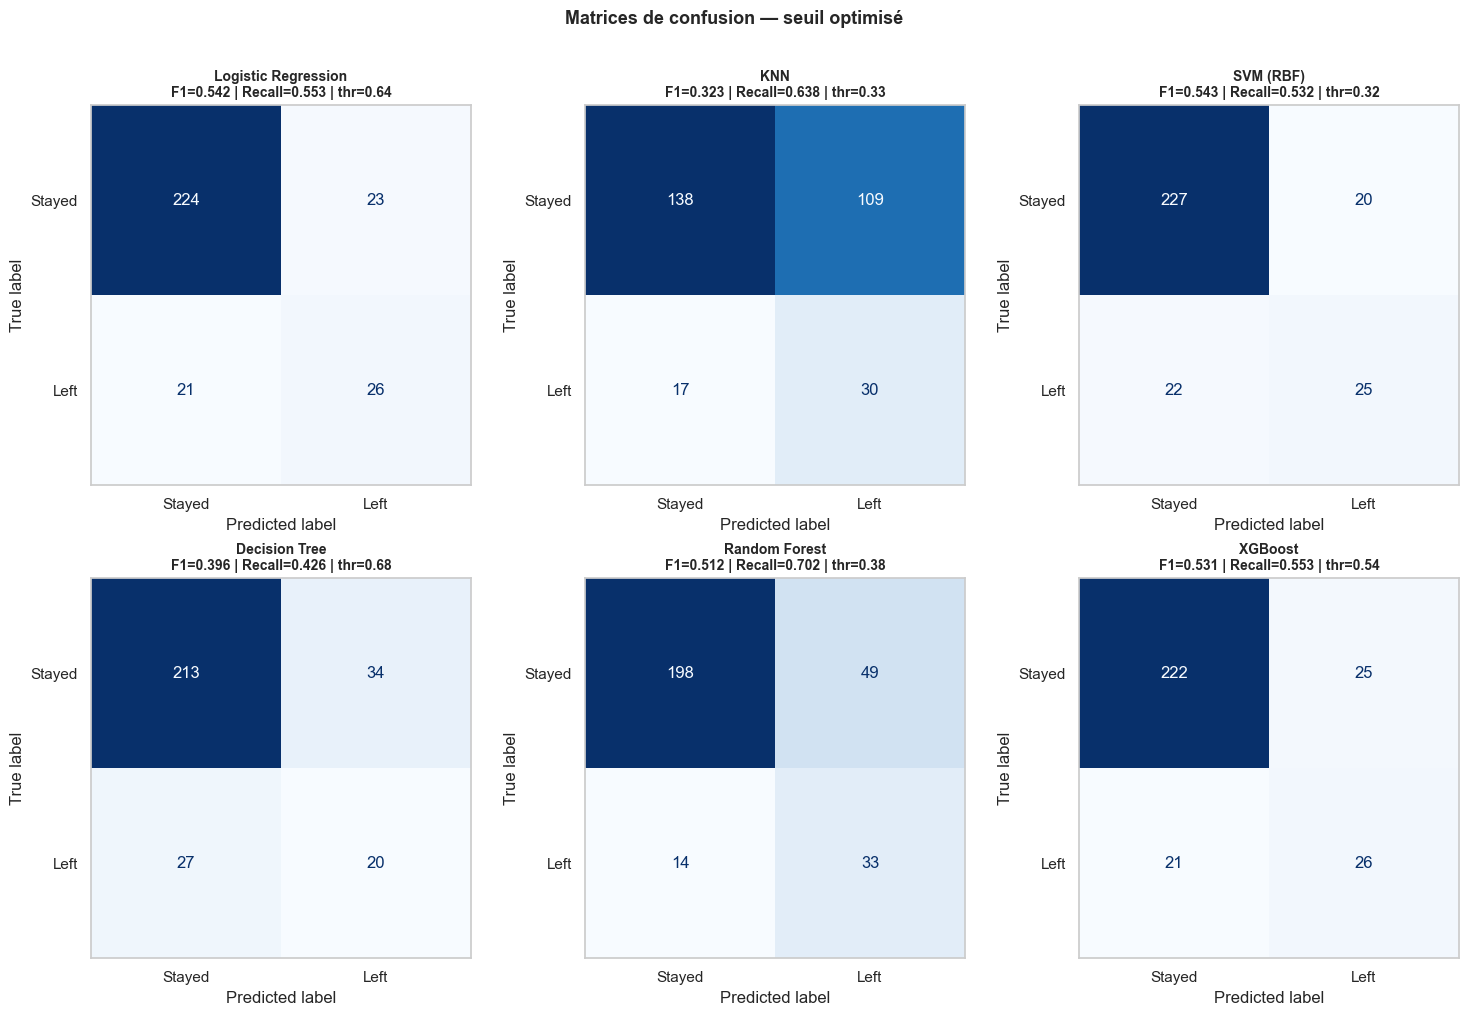

In [44]:
n = len(results_opt)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows))
axes = axes.flatten()

for i, r in enumerate(results_opt):
    cm = confusion_matrix(y_test, r["_y_pred_opt"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Left"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False, values_format="d")
    axes[i].set_title(
        f"{r['Model']}\nF1={r['F1_opt']:.3f} | Recall={r['Recall_opt']:.3f} | thr={r['Best_threshold']:.2f}",
        fontsize=10, fontweight="bold"
    )
    axes[i].grid(False)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.suptitle("Matrices de confusion — seuil optimisé", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Étape 7 — Courbes ROC comparées

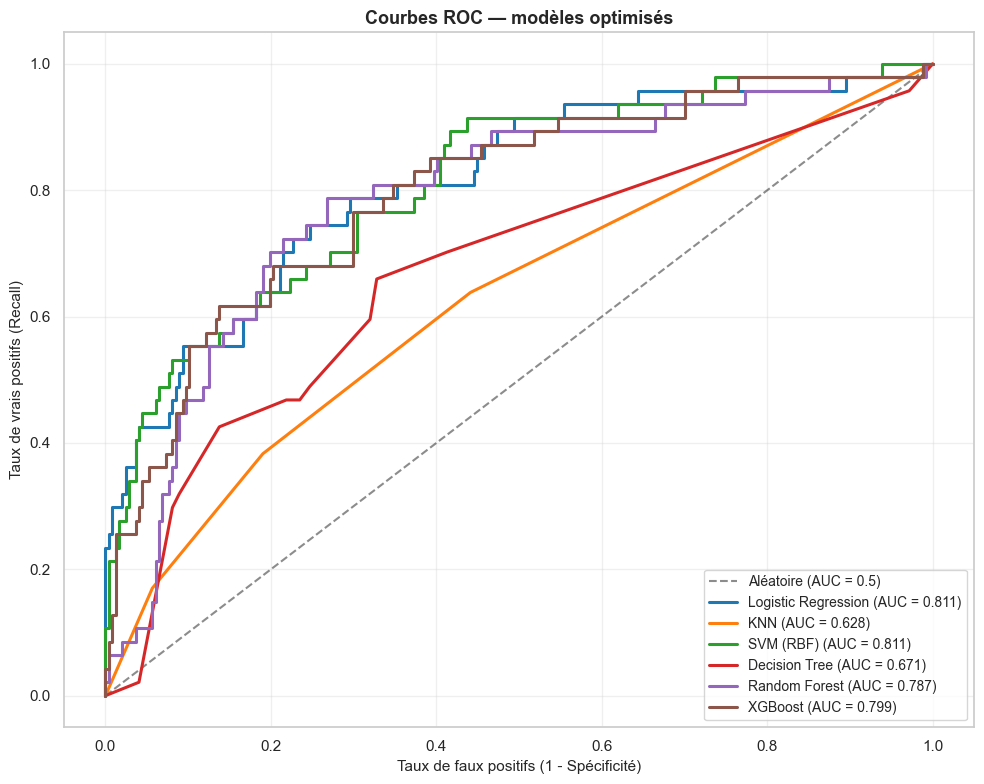

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire (AUC = 0.5)")

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
for r, c in zip(results_opt, colors):
    fpr, tpr, _ = roc_curve(y_test, r["_y_proba"])
    ax.plot(fpr, tpr, color=c, linewidth=2.2,
            label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})")

ax.set_xlabel("Taux de faux positifs (1 - Spécificité)", fontsize=11)
ax.set_ylabel("Taux de vrais positifs (Recall)", fontsize=11)
ax.set_title("Courbes ROC — modèles optimisés", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Étape 8 — Feature importance du meilleur modèle

In [46]:
best_model = best_res["_model"]

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train_enc.columns)
    title_prefix = "Feature importance (Gini/Gain)"
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X_train_enc.columns)
    title_prefix = "Feature importance (|coefficients|)"
else:
    importances = None

if importances is not None:
    top20 = importances.sort_values(ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 8))
    top20.sort_values().plot(kind="barh", ax=ax, color="#4878CF", edgecolor="white")
    ax.set_title(f"{title_prefix} — {best_res['Model']}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features :")
    print(top20.head(10).round(4))
else:
    print(f"Le modèle {best_res['Model']} ne fournit pas de feature importance directe.")


Le modèle SVM (RBF) ne fournit pas de feature importance directe.


## 🏆 Bilan final — recommandation


In [47]:
print("=" * 70)
print("BILAN — v3 (SMOTENC seul) vs v4 (optimisé)")
print("=" * 70)

# Champions par métrique
best_f1     = max(results_opt, key=lambda r: r["F1_opt"])
best_recall = max(results_opt, key=lambda r: r["Recall_opt"])
best_auc    = max(results_opt, key=lambda r: r["ROC-AUC"])

print(f"\n🥇 Meilleur F1     : {best_f1['Model']:<22} F1  = {best_f1['F1_opt']:.4f}")
print(f"🎯 Meilleur Recall : {best_recall['Model']:<22} Rec = {best_recall['Recall_opt']:.4f}")
print(f"📈 Meilleur AUC    : {best_auc['Model']:<22} AUC = {best_auc['ROC-AUC']:.4f}")

print("\n" + "=" * 70)
print("RECOMMANDATION FINALE")
print("=" * 70)
print(f"""
Le modèle à retenir pour la prédiction d'attrition est :

  ➜ {best_f1['Model']}
    Hyperparamètres : {best_f1['Best_params']}
    Seuil de décision : {best_f1['Best_threshold']}

Métriques finales sur le test set (réaliste, non-oversamplé) :
  • Accuracy  : {best_f1['Accuracy_opt']:.4f}
  • Precision : {best_f1['Precision_opt']:.4f}
  • Recall    : {best_f1['Recall_opt']:.4f}
  • F1-score  : {best_f1['F1_opt']:.4f}
  • ROC-AUC   : {best_f1['ROC-AUC']:.4f}

Interprétation métier :
  → Sur 100 employés que le modèle marque "à risque",
    ~{best_f1['Precision_opt']*100:.0f} vont réellement quitter.
  → Sur 100 employés qui vont réellement quitter,
    le modèle en détecte ~{best_f1['Recall_opt']*100:.0f}.
""")


BILAN — v3 (SMOTENC seul) vs v4 (optimisé)

🥇 Meilleur F1     : SVM (RBF)              F1  = 0.5435
🎯 Meilleur Recall : Random Forest          Rec = 0.7021
📈 Meilleur AUC    : SVM (RBF)              AUC = 0.8111

RECOMMANDATION FINALE

Le modèle à retenir pour la prédiction d'attrition est :

  ➜ SVM (RBF)
    Hyperparamètres : {'C': 1.0, 'gamma': 0.01}
    Seuil de décision : 0.321

Métriques finales sur le test set (réaliste, non-oversamplé) :
  • Accuracy  : 0.8571
  • Precision : 0.5556
  • Recall    : 0.5319
  • F1-score  : 0.5435
  • ROC-AUC   : 0.8111

Interprétation métier :
  → Sur 100 employés que le modèle marque "à risque",
    ~56 vont réellement quitter.
  → Sur 100 employés qui vont réellement quitter,
    le modèle en détecte ~53.



In [ ]:
# ============================================================
# EXPORT DES ARTEFACTS POUR L'API
# ============================================================
import joblib
import json
from pathlib import Path

# Dossier de sortie (même niveau que le notebook)
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# 1) Le modèle champion
best_model   = best_res["_model"]
best_thr     = float(best_res["Best_threshold"])
best_name    = best_res["Model"]

joblib.dump(best_model, ARTIFACTS_DIR / "model.joblib")

# 2) Le scaler (nécessaire seulement si LR/KNN/SVM a gagné,
#    mais on le sauvegarde toujours par sécurité)
joblib.dump(scaler_opt, ARTIFACTS_DIR / "scaler.joblib")

# 3) Les colonnes finales après one-hot (ordre IMPORTANT)
feature_columns = X_train_enc.columns.tolist()

# 4) Les colonnes brutes attendues en entrée (avant one-hot)
raw_input_columns = X_train_raw.columns.tolist()

# 5) Les modalités possibles par colonne catégorielle (pour Swagger)
categorical_choices = {
    col: sorted(X_train_raw[col].dropna().unique().tolist())
    for col in X_train_raw.select_dtypes(include=["object"]).columns
}

# 6)   Métadonnées
metadata = {
    "model_name":         best_name,
    "best_threshold":     best_thr,
    "needs_scaling":      best_name in ["LogisticRegression", "KNN", "SVM"],
    "feature_columns":    feature_columns,
    "raw_input_columns":  raw_input_columns,
    "categorical_choices": categorical_choices,
    "metrics": {
        "accuracy":  float(best_res["Accuracy_opt"]),
        "precision": float(best_res["Precision_opt"]),
        "recall":    float(best_res["Recall_opt"]),
        "f1":        float(best_res["F1_opt"]),
        "roc_auc":   float(best_res["ROC-AUC"]),
    },
}
with open(ARTIFACTS_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("✅ Artefacts exportés dans ./artifacts/")
print(f"   • model.joblib     ({best_name})")
print(f"   • scaler.joblib")
print(f"   • metadata.json    (seuil={best_thr}, {len(feature_columns)} features)")


✅ Artefacts exportés dans ./artifacts/
   • model.joblib     (SVM (RBF))
   • scaler.joblib
   • metadata.json    (seuil=0.321, 37 features)
